In [2]:
import pickle

# Load the pickle files
with open('X_train.pkl', 'rb') as f:
    X_train = pickle.load(f)

with open('X_test.pkl', 'rb') as f:
    X_test = pickle.load(f)

with open('y_train.pkl', 'rb') as f:
    y_train = pickle.load(f)

with open('y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)

with open('df_cleaned.pkl', 'rb') as f:
    df_cleaned = pickle.load(f)


FileNotFoundError: [Errno 2] No such file or directory: 'X_train.pkl'

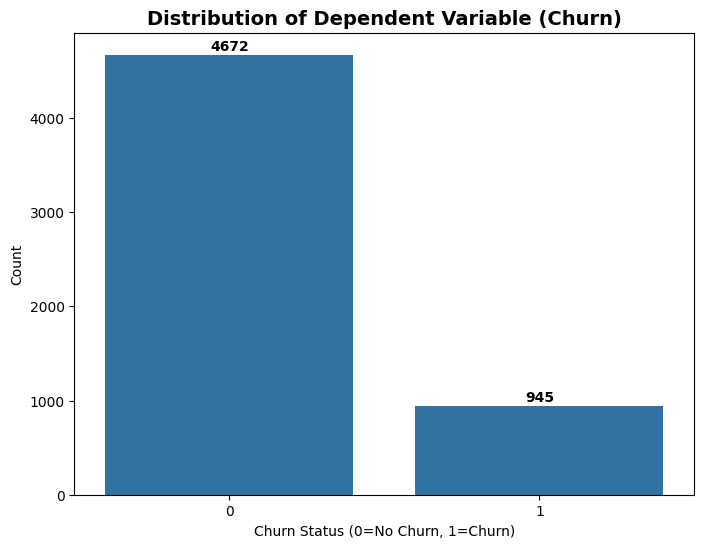

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


# Combine train and test target variables for full distribution
y_full = pd.concat([y_train, y_test], ignore_index=True)

# Plot 1: Distribution of Dependent Variable - Bar Plot
plt.figure(figsize=(8, 6))
sns.countplot(x=y_full, order=[0, 1])
plt.title('Distribution of Dependent Variable (Churn)', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status (0=No Churn, 1=Churn)')
plt.ylabel('Count')
# Add count labels on top of bars
for i, v in enumerate(y_full.value_counts().sort_index()):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.show()


Vast majority of our dataset is on people who did not churn. Dataset is imbalanced and will need to take this into consideration when doing further analysis.

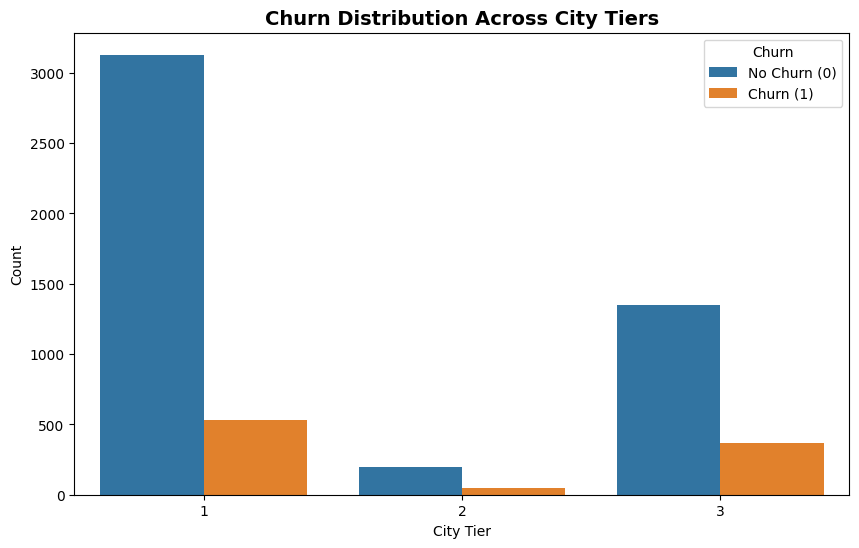

In [5]:
# Combine train and test data for full dataset analysis
X_full = pd.concat([X_train, X_test], ignore_index=True)
y_full = pd.concat([y_train, y_test], ignore_index=True)

# Create a combined dataframe for easier analysis
df_full = X_full.copy()
df_full['Churn'] = y_full

# Plot 2: Churn Distribution Across a Key Categorical Variable
# Look at how churn varies by CityTier or another categorical variable
plt.figure(figsize=(10, 6))
sns.countplot(data=df_full, x='CityTier', hue='Churn', order=sorted(df_full['CityTier'].unique()))
plt.title('Churn Distribution Across City Tiers', fontsize=14, fontweight='bold')
plt.xlabel('City Tier')
plt.ylabel('Count')
plt.legend(title='Churn', labels=['No Churn (0)', 'Churn (1)'])
plt.show()


From first look, 'CityTier' does not seem to be a major factor in terms of whether a customer churns or not. Possibly indicating a non-useful feature. However, instead of counts will compare across percentage terms because there is not as much data in tier 2 and 3 cities.

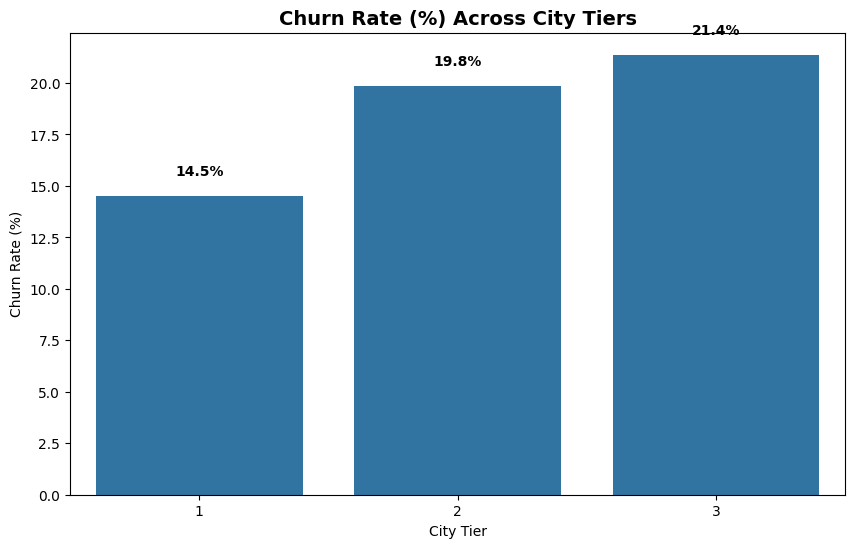

In [6]:
# Plot 3: Churn Rate (Percentage) Across City Tiers
churn_by_tier = df_full.groupby('CityTier')['Churn'].agg(['count', 'sum']).reset_index()
churn_by_tier['ChurnRate'] = (churn_by_tier['sum'] / churn_by_tier['count']) * 100
churn_by_tier = churn_by_tier.sort_values('CityTier')

plt.figure(figsize=(10, 6))
sns.barplot(data=churn_by_tier, x='CityTier', y='ChurnRate', order=sorted(churn_by_tier['CityTier'].unique()))
plt.title('Churn Rate (%) Across City Tiers', fontsize=14, fontweight='bold')
plt.xlabel('City Tier')
plt.ylabel('Churn Rate (%)')
# Add percentage labels on top of bars
for i, row in churn_by_tier.iterrows():
    plt.text(row['CityTier'] - 1, row['ChurnRate'] + 1, f"{row['ChurnRate']:.1f}%", 
             ha='center', fontweight='bold')
plt.show()


From this graph, we can see that 'CityTier' has more of an effect on whether a customer churns or not than previously thought. However, still does not seem to be too important. However, the higher churn rate in tier 2 and 3 cities may be do to possible worse internet connection? maybe greater logistical challenges? or possibly other different demographical features. Will need to explore further or create new features to help answer these questions.

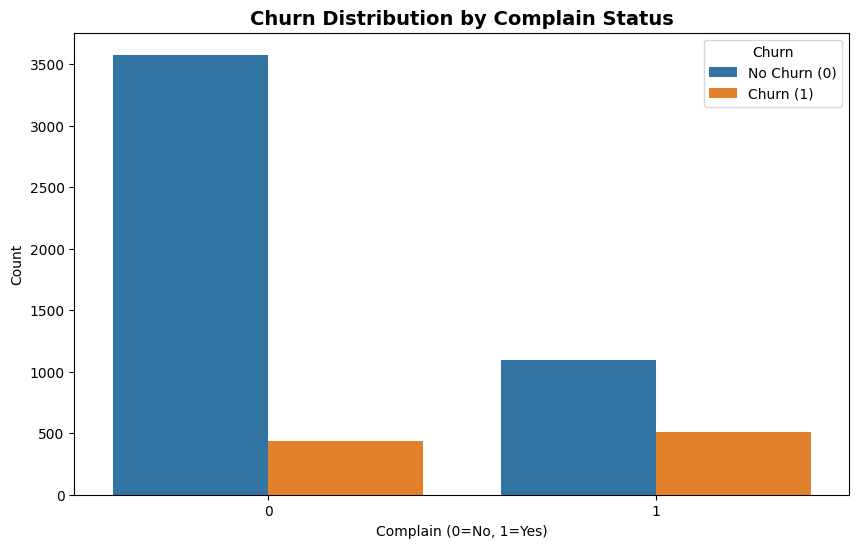

In [7]:
# Plot 4: Churn Distribution Across Complain Status
plt.figure(figsize=(10, 6))
sns.countplot(data=df_full, x='Complain', hue='Churn', order=sorted(df_full['Complain'].unique()))
plt.title('Churn Distribution by Complain Status', fontsize=14, fontweight='bold')
plt.xlabel('Complain (0=No, 1=Yes)')
plt.ylabel('Count')
plt.legend(title='Churn', labels=['No Churn (0)', 'Churn (1)'])
plt.show()


Graph intuitively shows that customers that do complain have higher counts of churning compared to those who do not complain.

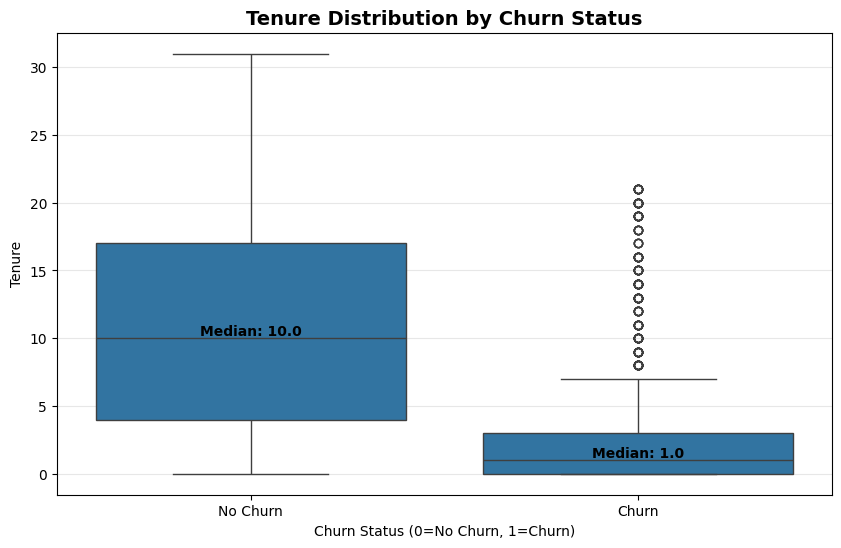

In [12]:
# Plot 5: Churn Distribution by Tenure - Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_full, x='Churn', y='Tenure', order=[0, 1])
plt.title('Tenure Distribution by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status (0=No Churn, 1=Churn)')
plt.ylabel('Tenure')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.grid(axis='y', alpha=0.3)

# Add median labels
for i, churn_val in enumerate([0, 1]):
    group_data = df_full[df_full['Churn'] == churn_val]['Tenure']
    median_val = group_data.median()
    plt.text(i, median_val, f'Median: {median_val:.1f}', ha='center', 
             va='bottom', fontweight='bold', fontsize=10)

plt.show()


Graph clearly shows that new customers are more likely to churn and their overall tenure is vastly shorter than those who don't churn. This result maybe due to poor customer service, mismatch between expectations or maybe other demographic/personality factors than can't be easily observed from the data.

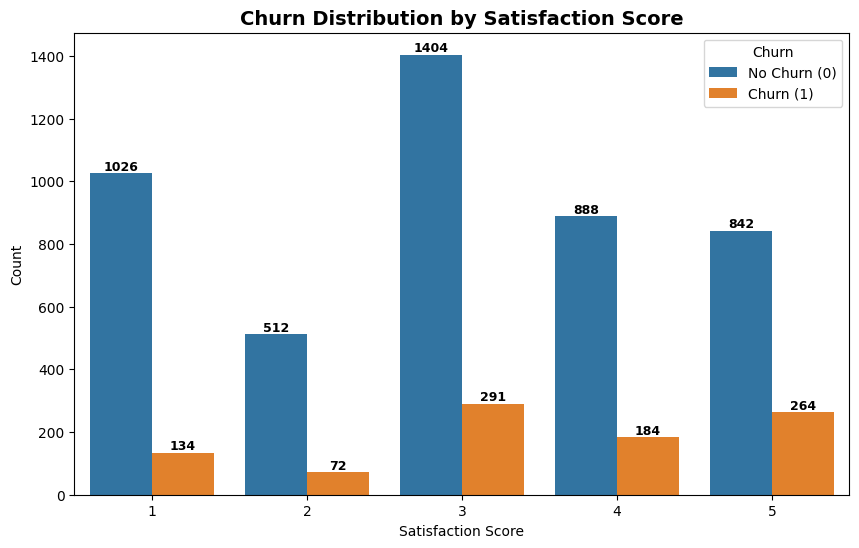

In [14]:
# Plot 6: Churn Distribution by Satisfaction Score
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_full, x='SatisfactionScore', hue='Churn', order=sorted(df_full['SatisfactionScore'].unique()))
plt.title('Churn Distribution by Satisfaction Score', fontsize=14, fontweight='bold')
plt.xlabel('Satisfaction Score')
plt.ylabel('Count')
plt.legend(title='Churn', labels=['No Churn (0)', 'Churn (1)'])

# Add count labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fontsize=9, fontweight='bold')

plt.show()


This had unexpectly high churn rate for customers with higher satisfaction scores. So we cant assume high satisfaction guarantees retention.

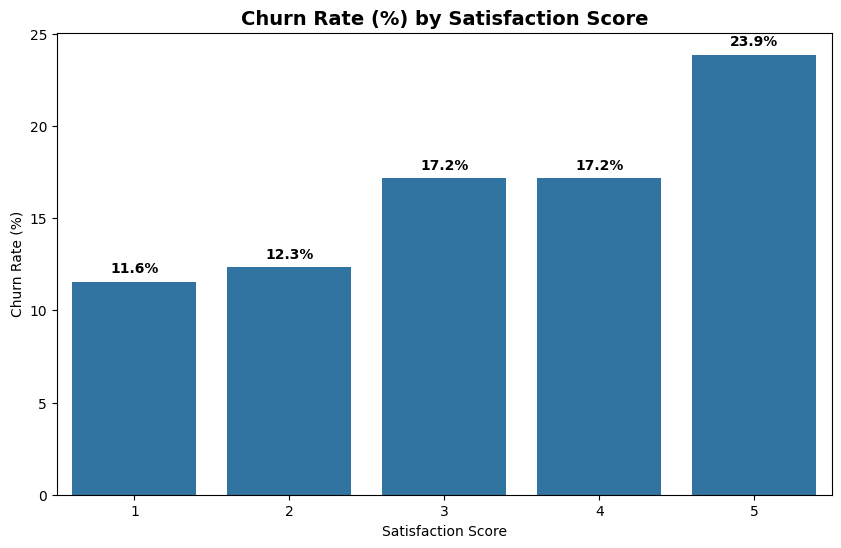

In [15]:
# Plot 7: Churn Rate (%) by Satisfaction Score
churn_by_score = df_full.groupby('SatisfactionScore')['Churn'].agg(['count', 'sum']).reset_index()
churn_by_score['ChurnRate'] = (churn_by_score['sum'] / churn_by_score['count']) * 100
churn_by_score = churn_by_score.sort_values('SatisfactionScore')

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=churn_by_score, x='SatisfactionScore', y='ChurnRate', order=sorted(churn_by_score['SatisfactionScore'].unique()))
plt.title('Churn Rate (%) by Satisfaction Score', fontsize=14, fontweight='bold')
plt.xlabel('Satisfaction Score')
plt.ylabel('Churn Rate (%)')

# Add percentage labels on top of bars
for i, row in churn_by_score.iterrows():
    plt.text(row['SatisfactionScore'] - 1, row['ChurnRate'] + 0.5, f"{row['ChurnRate']:.1f}%", 
             ha='center', fontweight='bold', fontsize=10)

plt.show()


Graph shows surprisingly higher churn rate for customers with higher satisfaction scores. Once again, only further confirming our previous belief that
high satisfaction scores guarantee retention.

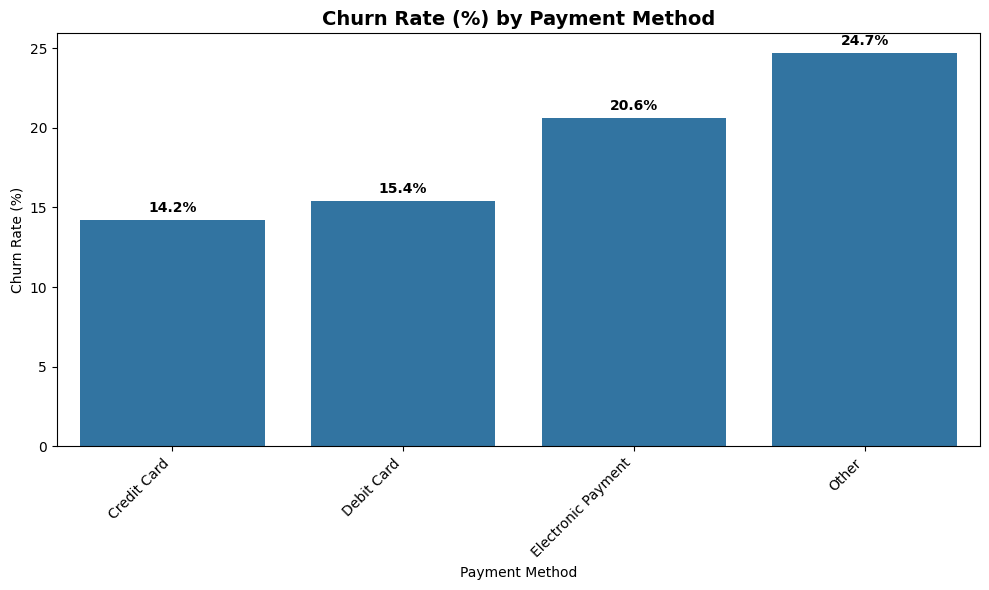

In [16]:
# Plot 8: Churn Rate by Payment Method
# Create a payment method column from dummy variables
df_full['PaymentMethod'] = 'Other'
df_full.loc[df_full['PreferredPaymentMode_Credit Card'] == 1, 'PaymentMethod'] = 'Credit Card'
df_full.loc[df_full['PreferredPaymentMode_Debit Card'] == 1, 'PaymentMethod'] = 'Debit Card'
df_full.loc[df_full['PreferredPaymentMode_Electronic Payment'] == 1, 'PaymentMethod'] = 'Electronic Payment'

churn_by_payment = df_full.groupby('PaymentMethod')['Churn'].agg(['count', 'sum']).reset_index()
churn_by_payment['ChurnRate'] = (churn_by_payment['sum'] / churn_by_payment['count']) * 100

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=churn_by_payment, x='PaymentMethod', y='ChurnRate', 
                 order=['Credit Card', 'Debit Card', 'Electronic Payment', 'Other'])
plt.title('Churn Rate (%) by Payment Method', fontsize=14, fontweight='bold')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45, ha='right')

# Add percentage labels on top of bars
for i, row in churn_by_payment.iterrows():
    payment_idx = ['Credit Card', 'Debit Card', 'Electronic Payment', 'Other'].index(row['PaymentMethod'])
    plt.text(payment_idx, row['ChurnRate'] + 0.5, f"{row['ChurnRate']:.1f}%", 
             ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


Graph shows that churn rates differ notably by payment method, indicating that payment behavior is linked to retention. Customers using credit cards (14.2%) and debit cards (15.4%) have the lowest churn, maybe due to more consistent and convenient payment habits such as saved cards or auto-pay. In contrast, electronic payment users (20.6%) and those in the “other” category (24.7%) are more likely to churn, which may reflect less commitment, higher price sensitivity, or less reliable payment experiences. 

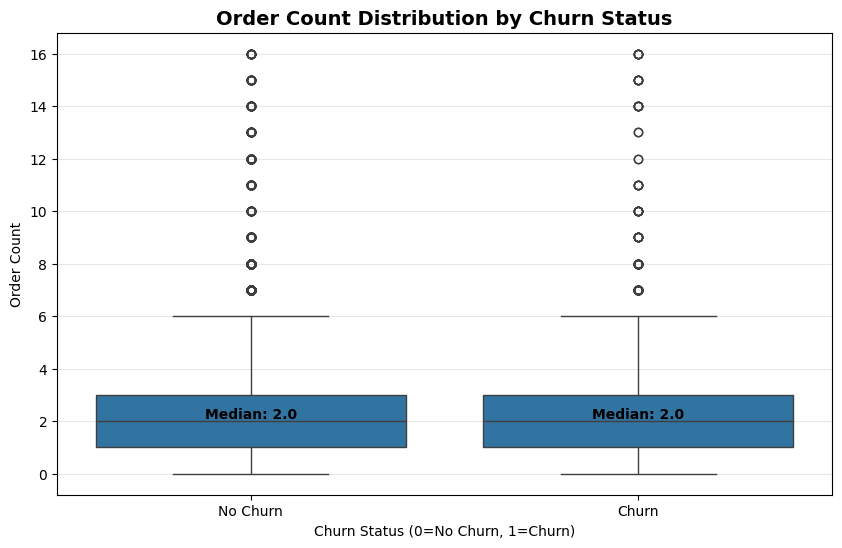

In [17]:
# Plot 9: Churn Distribution by Order Count (Box Plot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_full, x='Churn', y='OrderCount', order=[0, 1])
plt.title('Order Count Distribution by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status (0=No Churn, 1=Churn)')
plt.ylabel('Order Count')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.grid(axis='y', alpha=0.3)

# Add median labels
for i, churn_val in enumerate([0, 1]):
    group_data = df_full[df_full['Churn'] == churn_val]['OrderCount']
    median_val = group_data.median()
    plt.text(i, median_val, f'Median: {median_val:.1f}', ha='center', 
             va='bottom', fontweight='bold', fontsize=10)

plt.show()


The graph shows that order count is not a good predictor of churn.

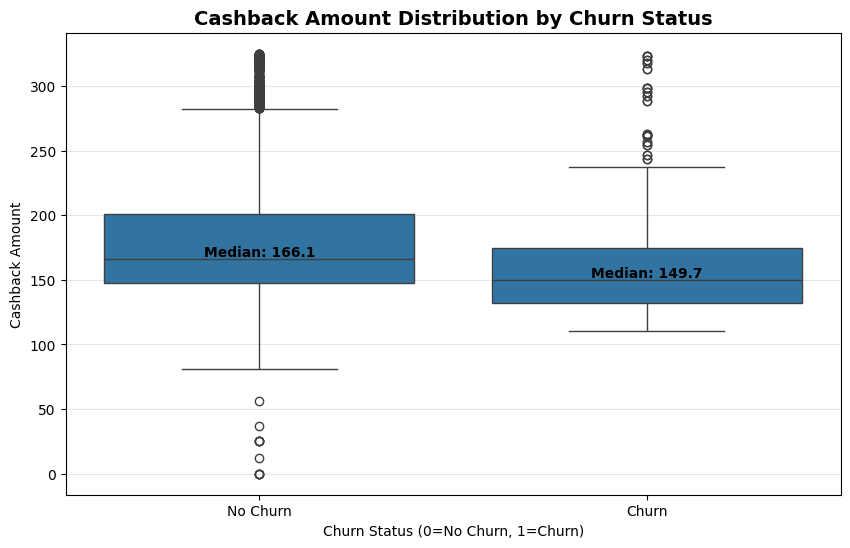

In [18]:
# Plot 10: Churn Distribution by Cashback Amount - Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_full, x='Churn', y='CashbackAmount', order=[0, 1])
plt.title('Cashback Amount Distribution by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status (0=No Churn, 1=Churn)')
plt.ylabel('Cashback Amount')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.grid(axis='y', alpha=0.3)

# Add median labels
for i, churn_val in enumerate([0, 1]):
    group_data = df_full[df_full['Churn'] == churn_val]['CashbackAmount']
    median_val = group_data.median()
    plt.text(i, median_val, f'Median: {median_val:.1f}', ha='center', 
             va='bottom', fontweight='bold', fontsize=10)

plt.show()


Boxplot shows that customers who did not churn have a slightly higher median cashback amount (166.1) than those who churned (149.7), suggesting that greater cashback incentives may be associated with better retention. The non-churn group also has more high-value outliers, indicating that loyal customers tend to earn higher cashback overall. However, the medians are relatively close, so the difference may not be practically significant, and extreme outliers could be influencing the spread. Other factors like tenure or order frequency may be driving both cashback and churn behavior.

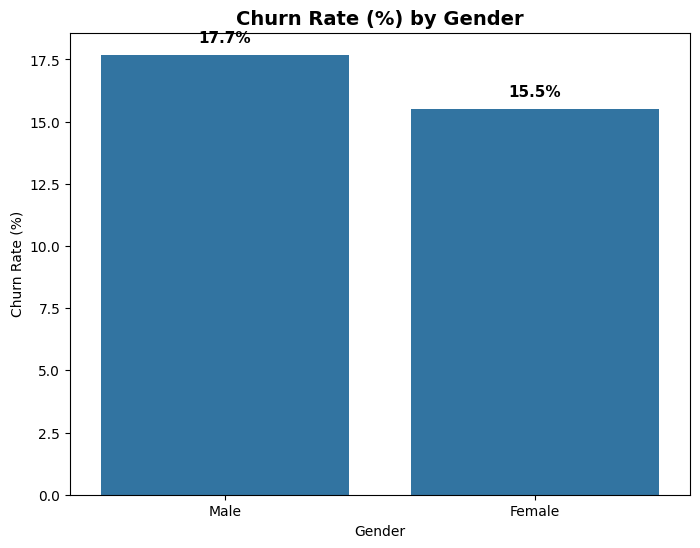

In [19]:
# Plot 11: Churn Rate by Gender
# Create a gender column from dummy variable
df_full['Gender'] = 'Female'
df_full.loc[df_full['Gender_Male'] == 1, 'Gender'] = 'Male'

churn_by_gender = df_full.groupby('Gender')['Churn'].agg(['count', 'sum']).reset_index()
churn_by_gender['ChurnRate'] = (churn_by_gender['sum'] / churn_by_gender['count']) * 100

plt.figure(figsize=(8, 6))
ax = sns.barplot(data=churn_by_gender, x='Gender', y='ChurnRate', order=['Male', 'Female'])
plt.title('Churn Rate (%) by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')

# Add percentage labels on top of bars
for i, row in churn_by_gender.iterrows():
    gender_idx = ['Male', 'Female'].index(row['Gender'])
    plt.text(gender_idx, row['ChurnRate'] + 0.5, f"{row['ChurnRate']:.1f}%", 
             ha='center', fontweight='bold', fontsize=11)

plt.show()


The graph shows that male customers have a slightly higher churn rate (17.7%) than female customers (15.5%), indicating only a modest difference in churn behavior by gender. This suggests that gender alone is likely not a strong predictor of churn.

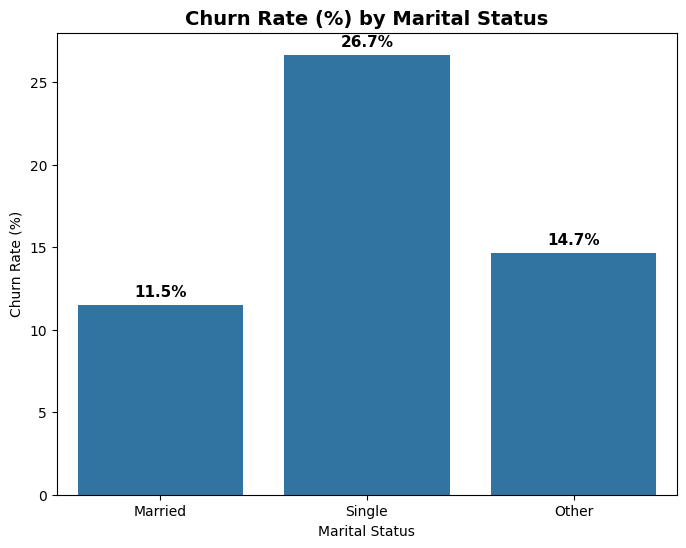

In [20]:
# Plot 12: Churn Rate by Marital Status
# Create a marital status column from dummy variables
df_full['MaritalStatus'] = 'Other'
df_full.loc[df_full['MaritalStatus_Married'] == 1, 'MaritalStatus'] = 'Married'
df_full.loc[df_full['MaritalStatus_Single'] == 1, 'MaritalStatus'] = 'Single'

churn_by_marital = df_full.groupby('MaritalStatus')['Churn'].agg(['count', 'sum']).reset_index()
churn_by_marital['ChurnRate'] = (churn_by_marital['sum'] / churn_by_marital['count']) * 100

plt.figure(figsize=(8, 6))
ax = sns.barplot(data=churn_by_marital, x='MaritalStatus', y='ChurnRate', 
                 order=['Married', 'Single', 'Other'])
plt.title('Churn Rate (%) by Marital Status', fontsize=14, fontweight='bold')
plt.xlabel('Marital Status')
plt.ylabel('Churn Rate (%)')

# Add percentage labels on top of bars
for i, row in churn_by_marital.iterrows():
    marital_idx = ['Married', 'Single', 'Other'].index(row['MaritalStatus'])
    plt.text(marital_idx, row['ChurnRate'] + 0.5, f"{row['ChurnRate']:.1f}%", 
             ha='center', fontweight='bold', fontsize=11)

plt.show()


The chart shows that single customers have a noticeably higher churn rate (26.7%) compared to married customers (11.5%) and those in the “other” category (14.7%), suggesting marital status may be associated with differences in customer stability or loyalty. This could reflect lifestyle differences, financial priorities, or varying levels of long-term commitment.

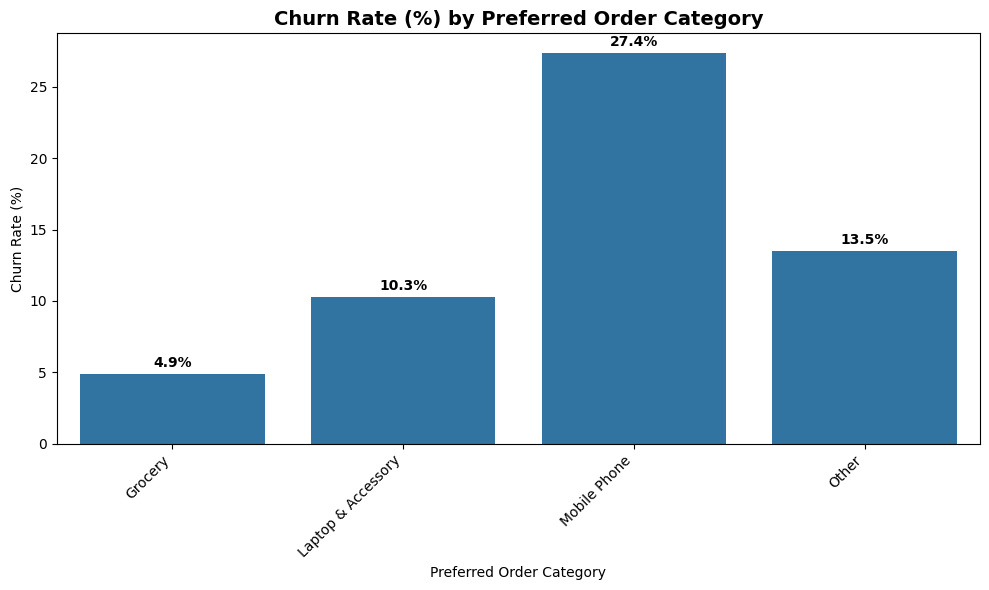

In [46]:
# Plot 13: Churn Distribution by Preferred Order Category
# Create an order category column from dummy variables
df_full['OrderCategory'] = 'Other'
df_full.loc[df_full['PreferredOrderCat_Grocery'] == 1, 'OrderCategory'] = 'Grocery'
df_full.loc[df_full['PreferredOrderCat_Laptop & Accessory'] == 1, 'OrderCategory'] = 'Laptop & Accessory'
df_full.loc[df_full['PreferredOrderCat_Mobile Phone'] == 1, 'OrderCategory'] = 'Mobile Phone'

churn_by_category = df_full.groupby('OrderCategory')['Churn'].agg(['count', 'sum']).reset_index()
churn_by_category['ChurnRate'] = (churn_by_category['sum'] / churn_by_category['count']) * 100

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=churn_by_category, x='OrderCategory', y='ChurnRate', 
                 order=['Grocery', 'Laptop & Accessory', 'Mobile Phone', 'Other'])
plt.title('Churn Rate (%) by Preferred Order Category', fontsize=14, fontweight='bold')
plt.xlabel('Preferred Order Category')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45, ha='right')

# Add percentage labels on top of bars
for i, row in churn_by_category.iterrows():
    cat_idx = ['Grocery', 'Laptop & Accessory', 'Mobile Phone', 'Other'].index(row['OrderCategory'])
    plt.text(cat_idx, row['ChurnRate'] + 0.5, f"{row['ChurnRate']:.1f}%", 
             ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


The chart shows that customers who primarily purchase mobile phones have the highest churn rate (27.4%), while grocery customers have the lowest (4.9%), suggesting that one-time or infrequent high-ticket purchases may be tied to higher churn and essential, repeat purchases are linked to better retention. Laptop & accessory and “other” categories fall in the middle.

In [22]:
# Plot 14: Summary Statistics Table for Key Variables by Churn Status
summary_stats = df_full.groupby('Churn')[['Tenure', 'OrderCount', 'CashbackAmount', 'SatisfactionScore']].agg(['mean', 'median', 'std']).round(2)
print(summary_stats)


      Tenure              OrderCount              CashbackAmount          \
        mean median   std       mean median   std           mean  median   
Churn                                                                      
0      11.14   10.0  8.31       2.89    2.0  2.97         180.63  166.12   
1       3.36    1.0  5.26       2.76    2.0  2.80         160.38  149.69   

             SatisfactionScore               
         std              mean median   std  
Churn                                        
0      50.42              3.00    3.0  1.38  
1      38.45              3.39    3.0  1.34  


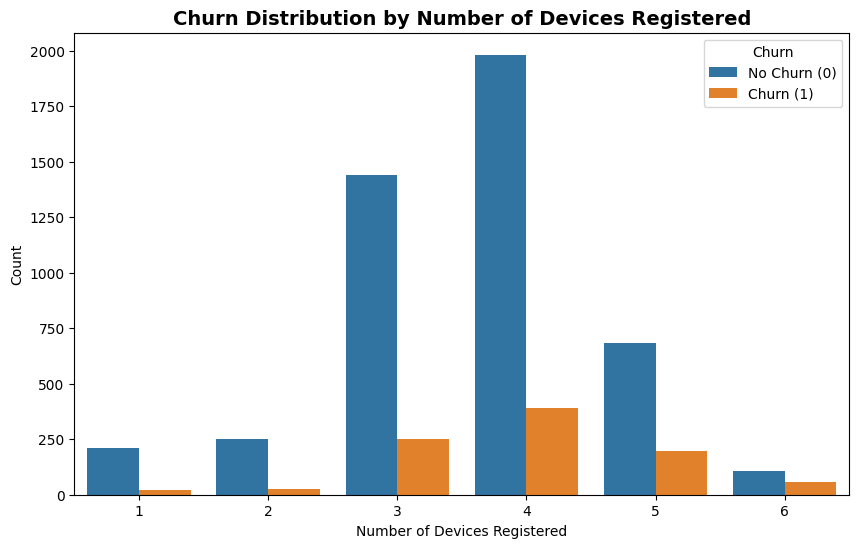

In [23]:
# Plot 15: Churn Distribution by Number of Devices Registered
plt.figure(figsize=(10, 6))
sns.countplot(data=df_full, x='NumberOfDeviceRegistered', hue='Churn', 
              order=sorted(df_full['NumberOfDeviceRegistered'].unique()))
plt.title('Churn Distribution by Number of Devices Registered', fontsize=14, fontweight='bold')
plt.xlabel('Number of Devices Registered')
plt.ylabel('Count')
plt.legend(title='Churn', labels=['No Churn (0)', 'Churn (1)'])
plt.show()


This chart shows that customers with 3–4 registered devices make up the largest portion of the user base, and while they also have the most churn in raw numbers, the majority in every device category still does not churn. Customers with only 1–2 devices show very low churn overall, likely reflecting more casual but stable users, while those with 5–6 devices may represent heavier users who still show a noticeable (though smaller) churn count due to the smaller sample size. Overall, having more devices appears to be associated with higher engagement, but also slightly higher exposure to churn risk simply because there are more opportunities for dissatisfaction or changes in usage patterns.

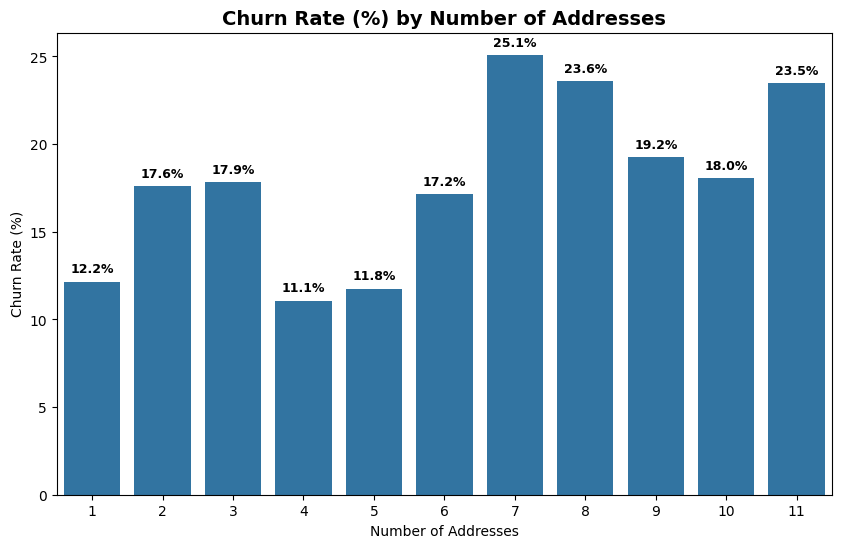

In [24]:
# Plot 16: Churn Rate by Number of Addresses
churn_by_address = df_full.groupby('NumberOfAddress')['Churn'].agg(['count', 'sum']).reset_index()
churn_by_address['ChurnRate'] = (churn_by_address['sum'] / churn_by_address['count']) * 100
churn_by_address = churn_by_address.sort_values('NumberOfAddress')

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=churn_by_address, x='NumberOfAddress', y='ChurnRate', 
                 order=sorted(churn_by_address['NumberOfAddress'].unique()))
plt.title('Churn Rate (%) by Number of Addresses', fontsize=14, fontweight='bold')
plt.xlabel('Number of Addresses')
plt.ylabel('Churn Rate (%)')

# Add percentage labels on top of bars
for i, row in churn_by_address.iterrows():
    addr_val = row['NumberOfAddress']
    plt.text(addr_val - 1, row['ChurnRate'] + 0.5, f"{row['ChurnRate']:.1f}%", 
             ha='center', fontweight='bold', fontsize=9)

plt.show()


This chart suggests that churn tends to increase as the number of addresses associated with a customer grows, though the relationship is not perfectly linear. Customers with just 1 address show the lowest churn rate (12.2%), while churn begins to rise for 2–3 addresses and then drops again around 4–5 addresses, indicating a brief stabilization. After 6 addresses, churn climbs sharply, peaking at 7 addresses (25.1%), and remaining elevated through higher address counts. This pattern may reflect that customers managing many addresses are more complex, less stable, or more likely to switch services, making number of addresses an important risk indicator for churn.

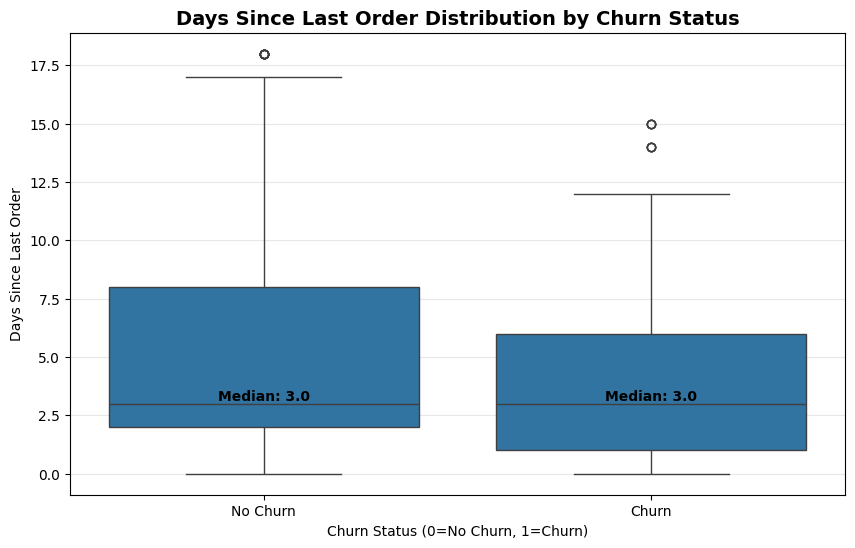

In [25]:
# Plot 17: Churn Distribution by Days Since Last Order (Box Plot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_full, x='Churn', y='DaySinceLastOrder', order=[0, 1])
plt.title('Days Since Last Order Distribution by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status (0=No Churn, 1=Churn)')
plt.ylabel('Days Since Last Order')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.grid(axis='y', alpha=0.3)

# Add median labels
for i, churn_val in enumerate([0, 1]):
    group_data = df_full[df_full['Churn'] == churn_val]['DaySinceLastOrder']
    median_val = group_data.median()
    plt.text(i, median_val, f'Median: {median_val:.1f}', ha='center', 
             va='bottom', fontweight='bold', fontsize=10)

plt.show()


Box plot shows that the median time since the last order is identical (3.0 days) for both customers who later churned and those who did not. However, customers who did not churn tend to have a slightly wider interquartile range and more extreme outliers (some waiting over 17 days), while churned customers show somewhat less variability overall and fewer very long gaps. This suggests that the raw recency of the last order alone is a very weak predictor of churn in this dataset.

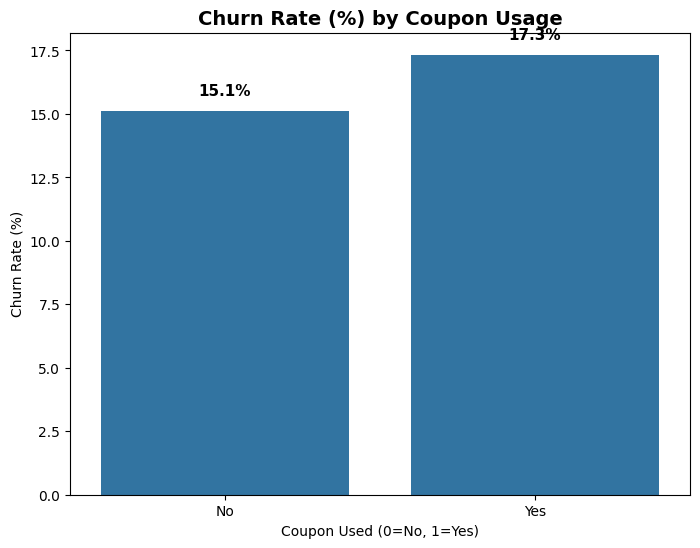

In [31]:
# Plot 18: Churn Rate by Coupon Usage
# Convert CouponUsed to binary (0 = No coupons, 1+ = Used coupons)
df_full['CouponUsed_Binary'] = (df_full['CouponUsed'] > 0).astype(int)

churn_by_coupon = df_full.groupby('CouponUsed_Binary')['Churn'].agg(['count', 'sum']).reset_index()
churn_by_coupon['ChurnRate'] = (churn_by_coupon['sum'] / churn_by_coupon['count']) * 100

# Create a dictionary for easy lookup
coupon_rates = dict(zip(churn_by_coupon['CouponUsed_Binary'], churn_by_coupon['ChurnRate']))

plt.figure(figsize=(8, 6))
ax = sns.barplot(data=churn_by_coupon, x='CouponUsed_Binary', y='ChurnRate', order=[0, 1])
plt.title('Churn Rate (%) by Coupon Usage', fontsize=14, fontweight='bold')
plt.xlabel('Coupon Used (0=No, 1=Yes)')
plt.ylabel('Churn Rate (%)')
plt.xticks([0, 1], ['No', 'Yes'])

# Add percentage labels on top of bars
plot_order = [0, 1]
for i, coupon_val in enumerate(plot_order):
    if coupon_val in coupon_rates:
        rate = coupon_rates[coupon_val]
        ax.text(i, rate + 0.5, f'{rate:.1f}%', ha='center', va='bottom', 
                fontweight='bold', fontsize=11)

plt.show()


This bar chart shows that customers who used a coupon have a higher churn rate (17.3%) than those who did not (15.1%), indicating that coupon usage is associated with an slightly increased likelihood of churn in this dataset. Contrary to common intuition, offering discounts appears to attract or retain more price-sensitive customers who are actually less loyal in the long run.

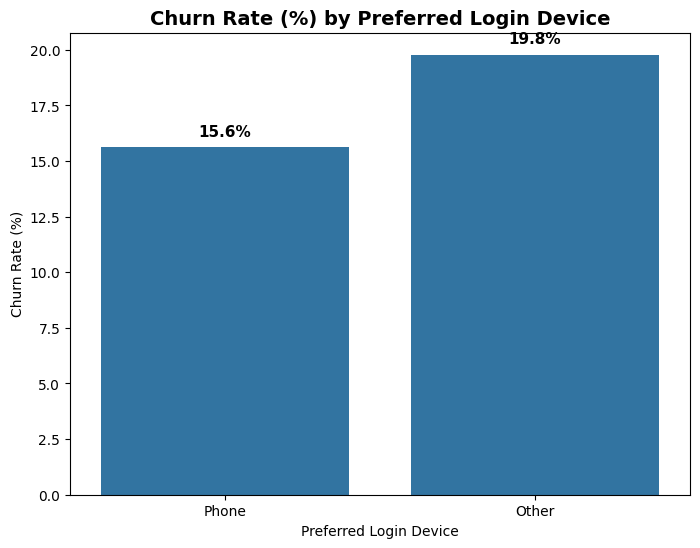

In [ ]:
# Plot 19: Churn Distribution by Preferred Login Device
churn_by_device = df_full.groupby('PreferredLoginDevice_Phone')['Churn'].agg(['count', 'sum']).reset_index()
churn_by_device['ChurnRate'] = (churn_by_device['sum'] / churn_by_device['count']) * 100
churn_by_device['Device'] = churn_by_device['PreferredLoginDevice_Phone'].map({True: 'Phone', False: 'Other'})

plt.figure(figsize=(8, 6))
ax = sns.barplot(data=churn_by_device, x='Device', y='ChurnRate', order=['Phone', 'Other'])
plt.title('Churn Rate (%) by Preferred Login Device', fontsize=14, fontweight='bold')
plt.xlabel('Preferred Login Device')
plt.ylabel('Churn Rate (%)')

# Add percentage labels on top of bars
for i, row in churn_by_device.iterrows():
    device_idx = ['Phone', 'Other'].index(row['Device'])
    plt.text(device_idx, row['ChurnRate'] + 0.5, f"{row['ChurnRate']:.1f}%", 
             ha='center', fontweight='bold', fontsize=11)

plt.show()


Bar chart reveals that customers whose preferred login device is "Other" have a higher churn rate (19.8%) than those who primarily use their phone (15.6%), suggesting that mobile-first users are more engaged and less likely to churn. This could reflect stronger habit formation or a better mobile experience that keeps phone users coming back

# Section 2: Variables of Special Interest

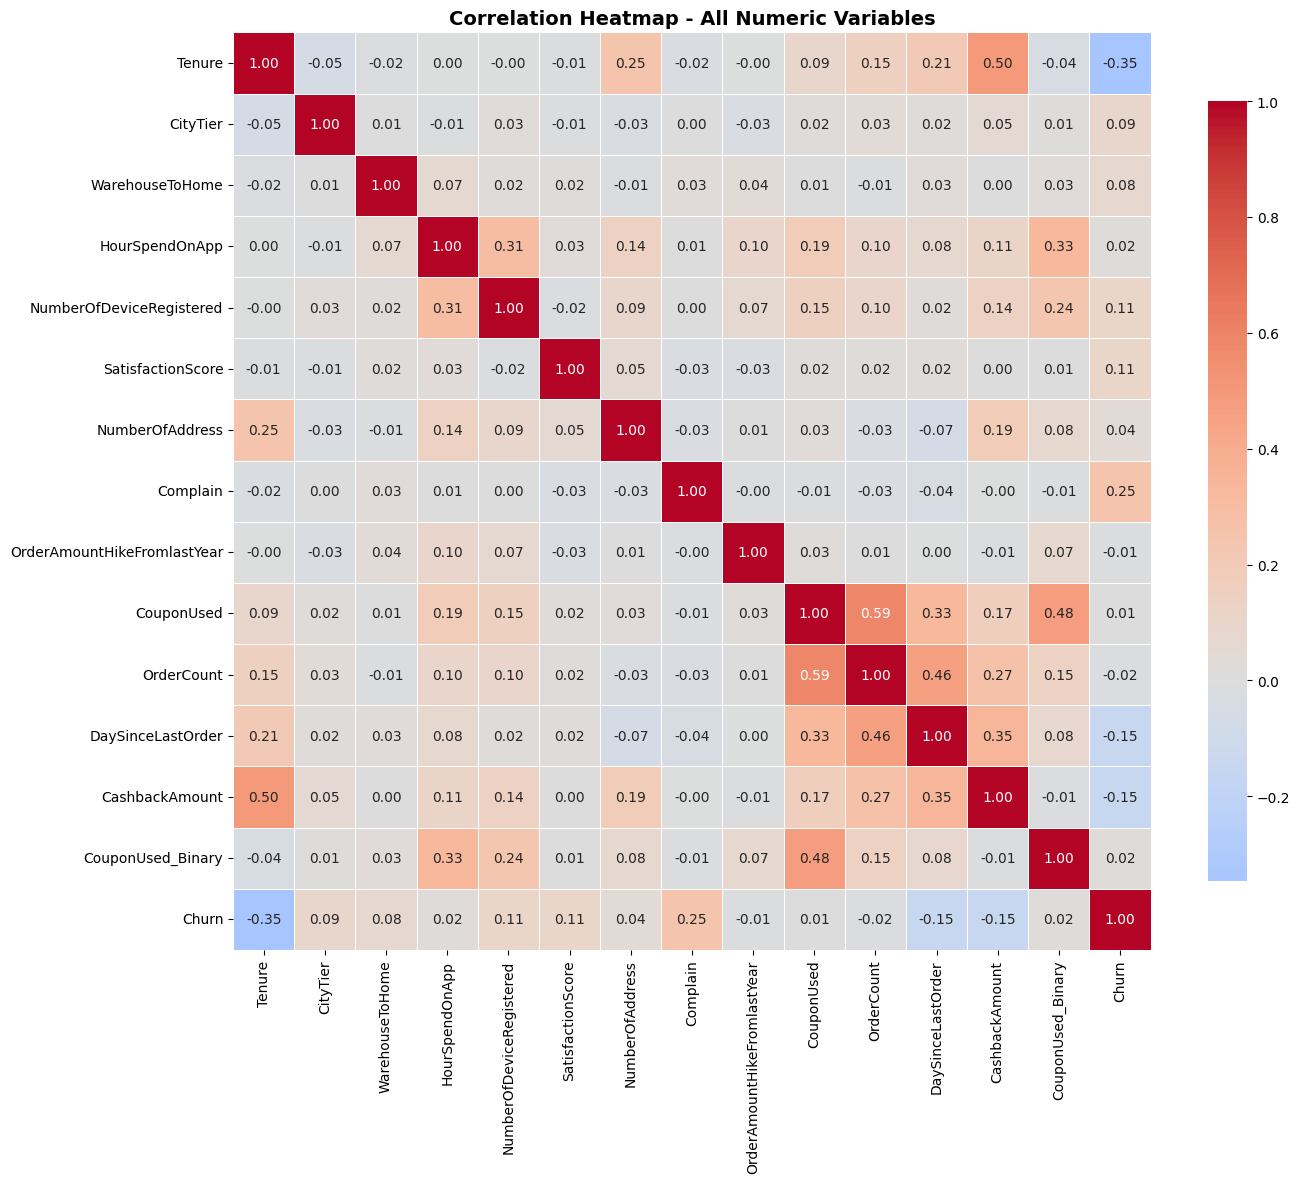

In [32]:
# Plot 20: Correlation Heatmap 
# Select numeric columns only
numeric_cols = df_full.select_dtypes(include=[np.number]).columns.tolist()
# Remove Churn from the list to show correlations with it
numeric_cols_for_corr = [col for col in numeric_cols if col != 'Churn']

# Create correlation matrix
corr_matrix = df_full[numeric_cols_for_corr + ['Churn']].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - All Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


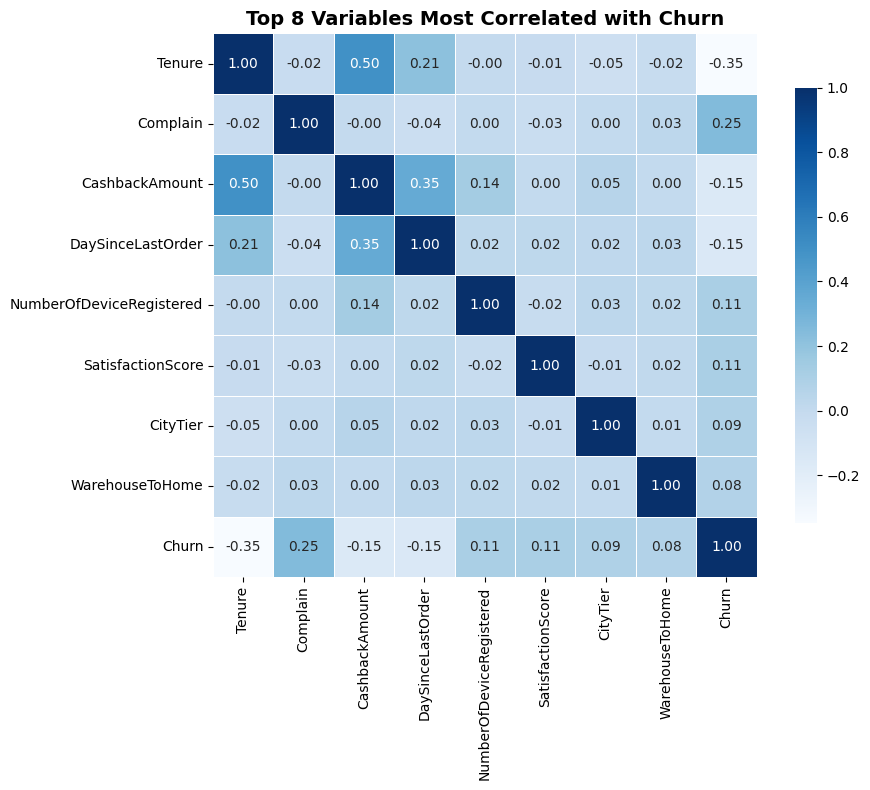

In [ ]:
# Plot 21: Focused Correlation Heatmap - Top Variables Correlated with Churn
# Get top k variables most correlated with Churn 
k = 8  # number of variables for heatmap
var_of_interest = 'Churn'

# Get numeric columns
numeric_cols = df_full.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'Churn']

# Calculate correlations with Churn
df_numeric = df_full[numeric_cols + ['Churn']]
corr_with_churn = df_numeric.corr()['Churn'].abs().sort_values(ascending=False)

# Get top k variables 
top_k_vars = corr_with_churn.head(k+1).index.tolist()
if 'Churn' in top_k_vars:
    top_k_vars.remove('Churn')
top_k_vars = top_k_vars[:k]
# Add Churn back for the heatmap
top_k_vars.append('Churn')  

# Create correlation matrix for top variables
cm = df_numeric[top_k_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', square=True, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title(f'Top {k} Variables Most Correlated with Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


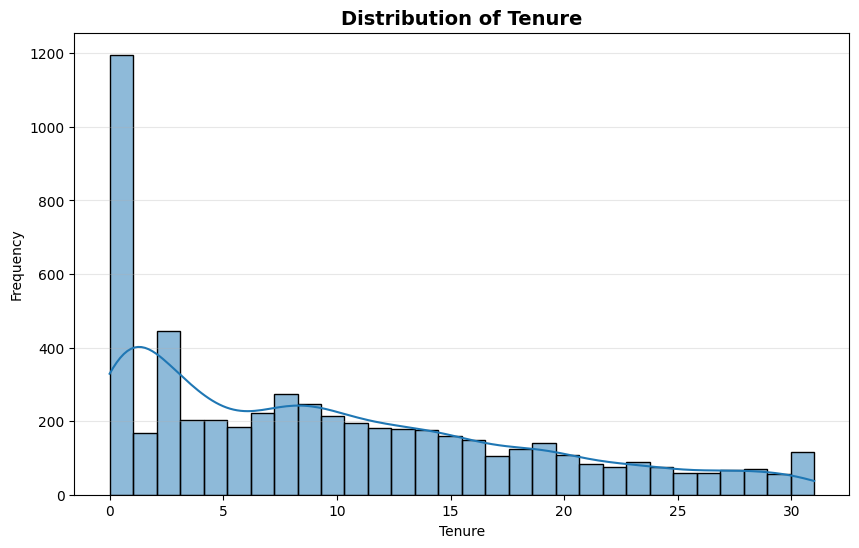

In [37]:
# Plot 21: Distribution of Tenure
plt.figure(figsize=(10, 6))
sns.histplot(data=df_full, x='Tenure', kde=True, bins=30)
plt.title('Distribution of Tenure', fontsize=14, fontweight='bold')
plt.xlabel('Tenure')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()


In [ ]:
## Right skewed distribution, most customers are new.

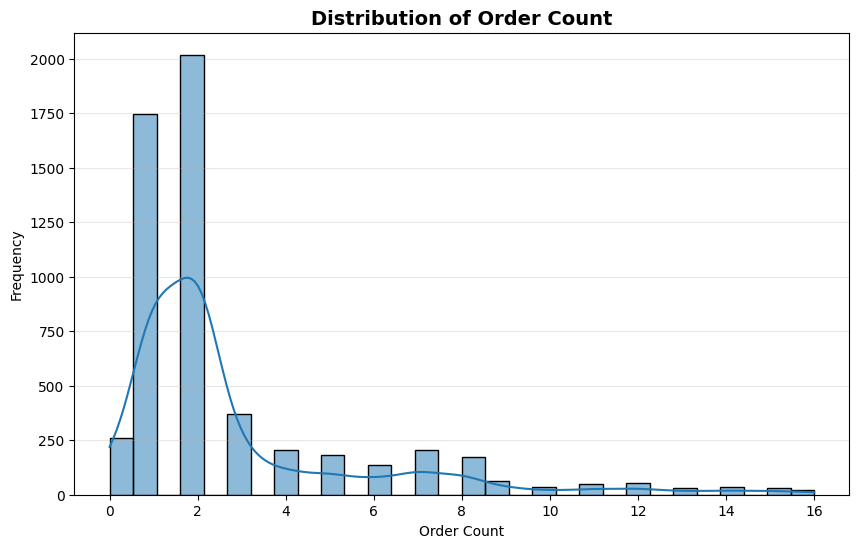

In [36]:
# Plot 22: Distribution of Order Count 
plt.figure(figsize=(10, 6))
sns.histplot(data=df_full, x='OrderCount', kde=True, bins=30)
plt.title('Distribution of Order Count', fontsize=14, fontweight='bold')
plt.xlabel('Order Count')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()


In [ ]:
## Strongly right skewed, most customers are low order count.
## High skew suggests a small group of frequent buyers


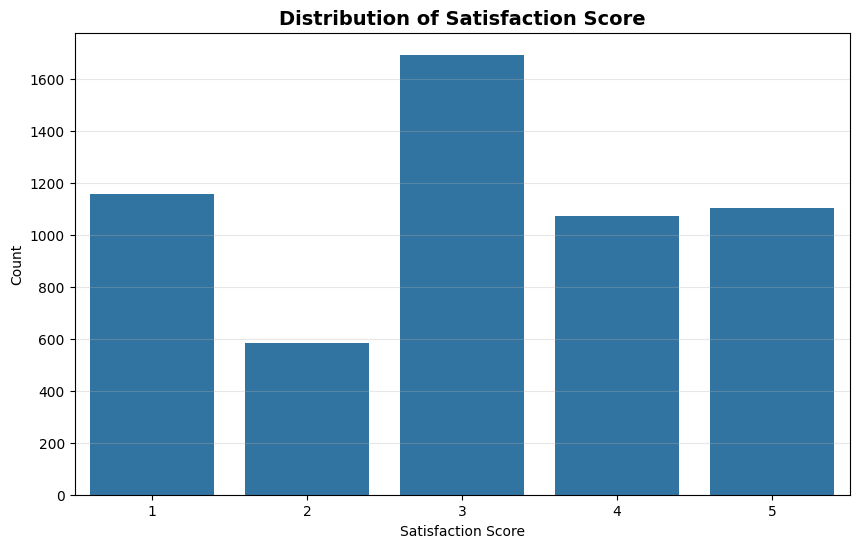

In [39]:
# Plot 23: Distribution of Satisfaction Score
plt.figure(figsize=(10, 6))
sns.countplot(data=df_full, x='SatisfactionScore', order=sorted(df_full['SatisfactionScore'].unique()))
plt.title('Distribution of Satisfaction Score', fontsize=14, fontweight='bold')
plt.xlabel('Satisfaction Score')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()


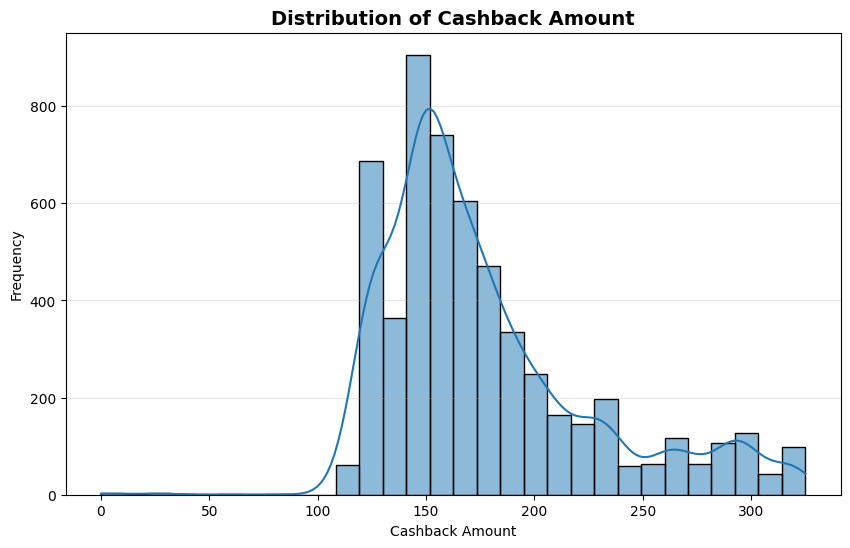

In [40]:
# Plot 24: Distribution of Cashback Amount
plt.figure(figsize=(10, 6))
sns.histplot(data=df_full, x='CashbackAmount', kde=True, bins=30)
plt.title('Distribution of Cashback Amount', fontsize=14, fontweight='bold')
plt.xlabel('Cashback Amount')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()


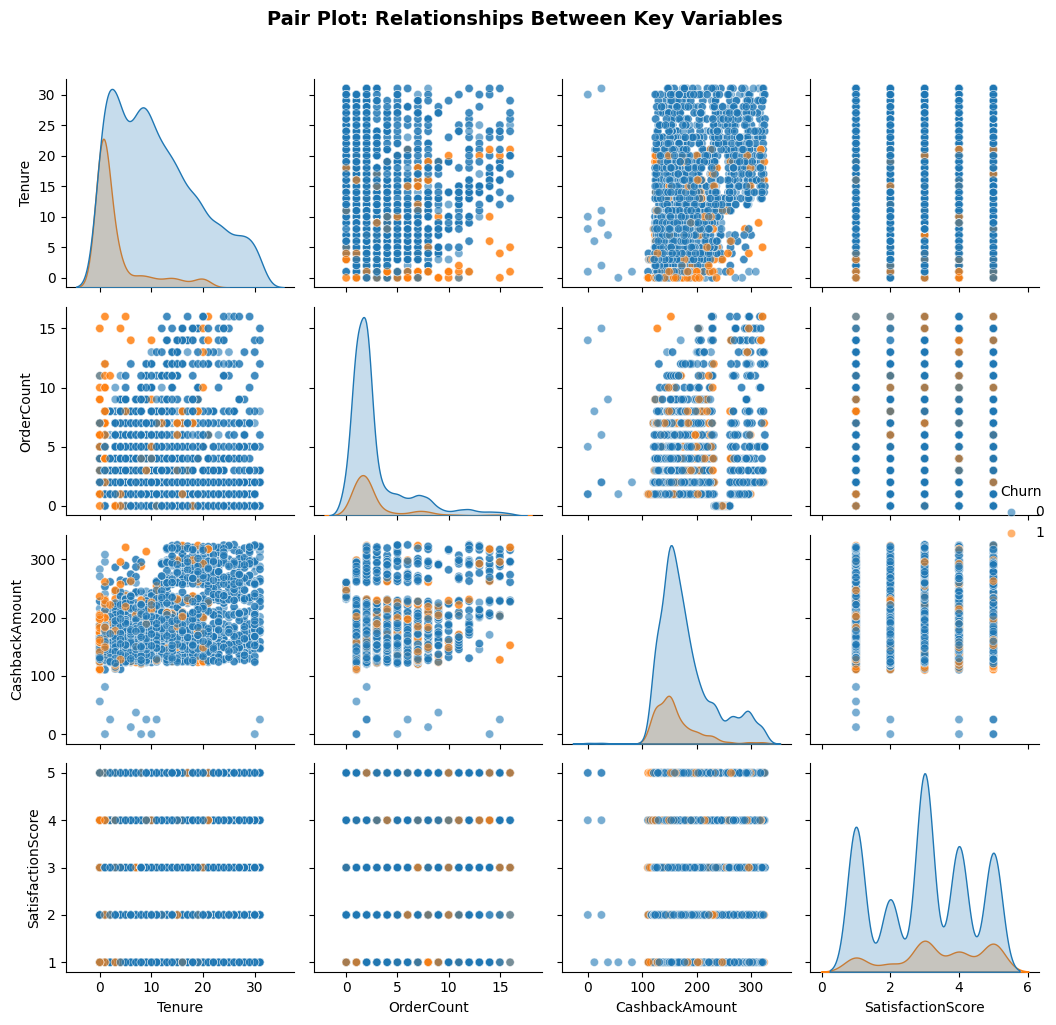

In [41]:
# Plot 25: Pair Plot - Key Variables 
# Select a subset of key numeric variables for pair plot
key_vars = ['Tenure', 'OrderCount', 'CashbackAmount', 'SatisfactionScore', 'Churn']

# Create pair plot with hue for Churn
sns.pairplot(df_full[key_vars], hue='Churn', diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot: Relationships Between Key Variables', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


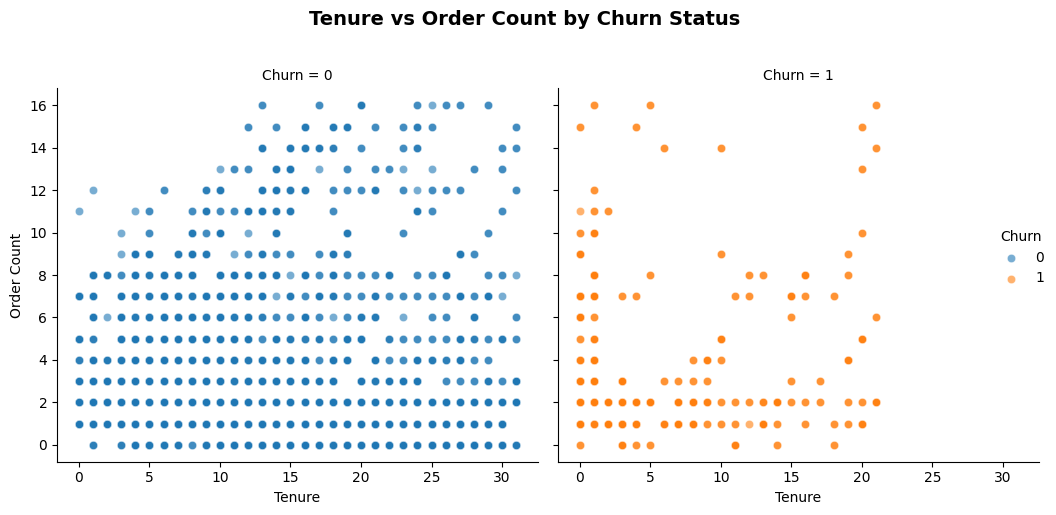

In [42]:
# Plot 26: Facet Grid - Tenure vs Order Count by Churn Status
g = sns.FacetGrid(df_full, col='Churn', hue='Churn', height=5)
g.map_dataframe(sns.scatterplot, x='Tenure', y='OrderCount', alpha=0.6)
g.add_legend()
g.set_axis_labels('Tenure', 'Order Count')
g.set_titles('Churn = {col_name}')
plt.suptitle('Tenure vs Order Count by Churn Status', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


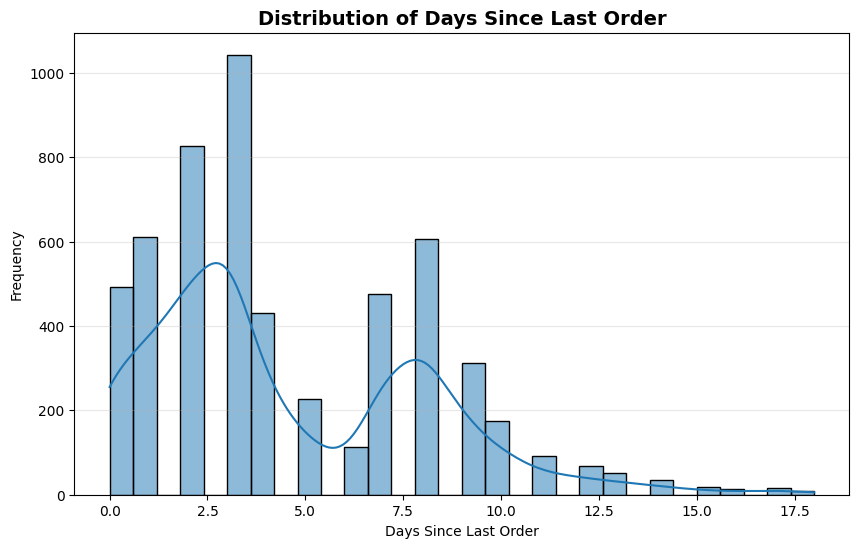

In [44]:
# Plot 28: Distribution of Days Since Last Order
plt.figure(figsize=(10, 6))
sns.histplot(data=df_full, x='DaySinceLastOrder', kde=True, bins=30)
plt.title('Distribution of Days Since Last Order', fontsize=14, fontweight='bold')
plt.xlabel('Days Since Last Order')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()


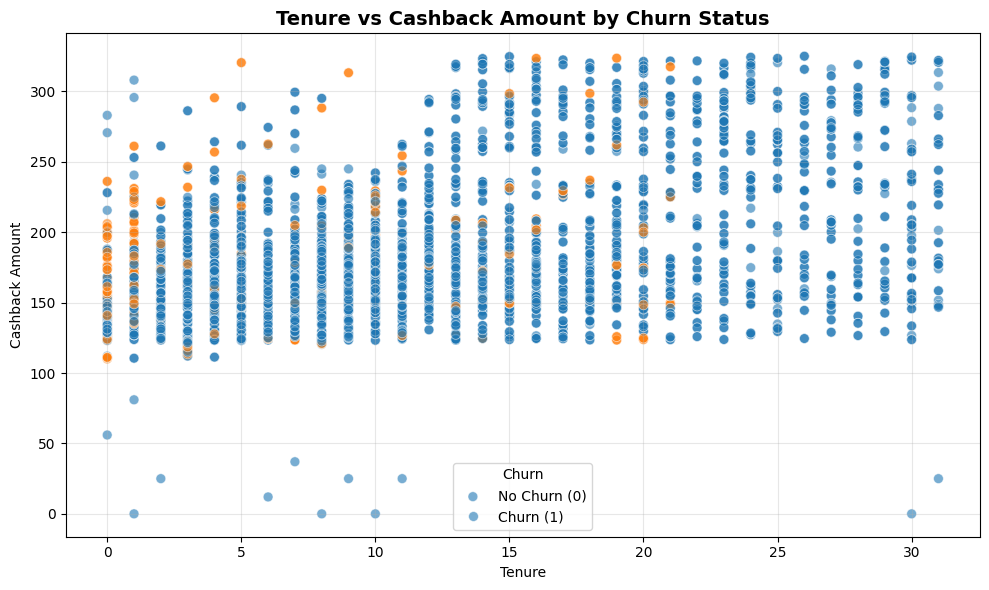

In [45]:
# Plot 29: Scatter Plot - Tenure vs Cashback Amount (colored by Churn)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_full, x='Tenure', y='CashbackAmount', hue='Churn', alpha=0.6, s=50)
plt.title('Tenure vs Cashback Amount by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Tenure')
plt.ylabel('Cashback Amount')
plt.legend(title='Churn', labels=['No Churn (0)', 'Churn (1)'])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


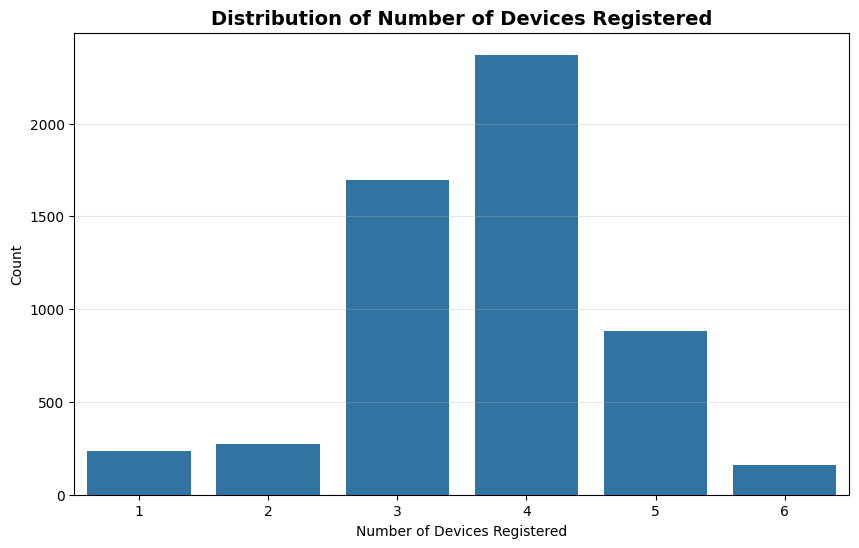

In [47]:
# Plot 30: Distribution of Number of Devices Registered
plt.figure(figsize=(10, 6))
sns.countplot(data=df_full, x='NumberOfDeviceRegistered', order=sorted(df_full['NumberOfDeviceRegistered'].unique()))
plt.title('Distribution of Number of Devices Registered', fontsize=14, fontweight='bold')
plt.xlabel('Number of Devices Registered')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()


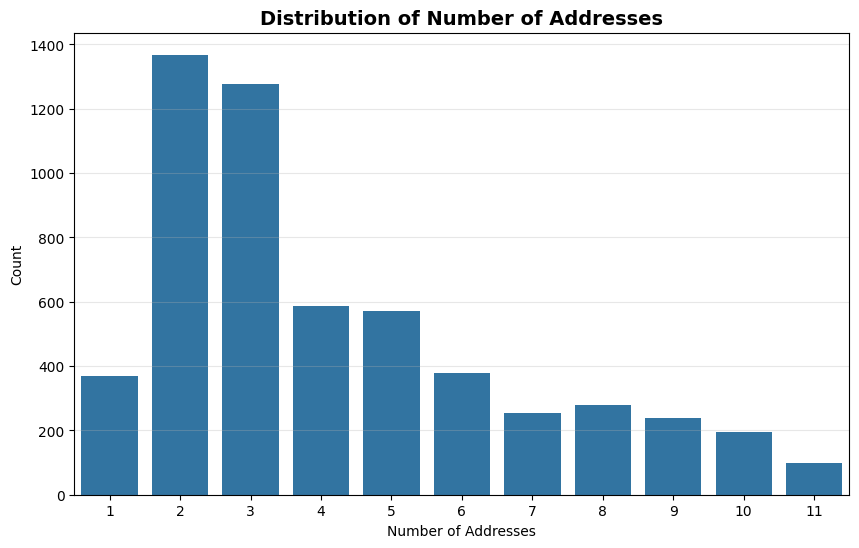

In [48]:
# Plot 31: Distribution of Number of Addresses
plt.figure(figsize=(10, 6))
sns.countplot(data=df_full, x='NumberOfAddress', order=sorted(df_full['NumberOfAddress'].unique()))
plt.title('Distribution of Number of Addresses', fontsize=14, fontweight='bold')
plt.xlabel('Number of Addresses')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()


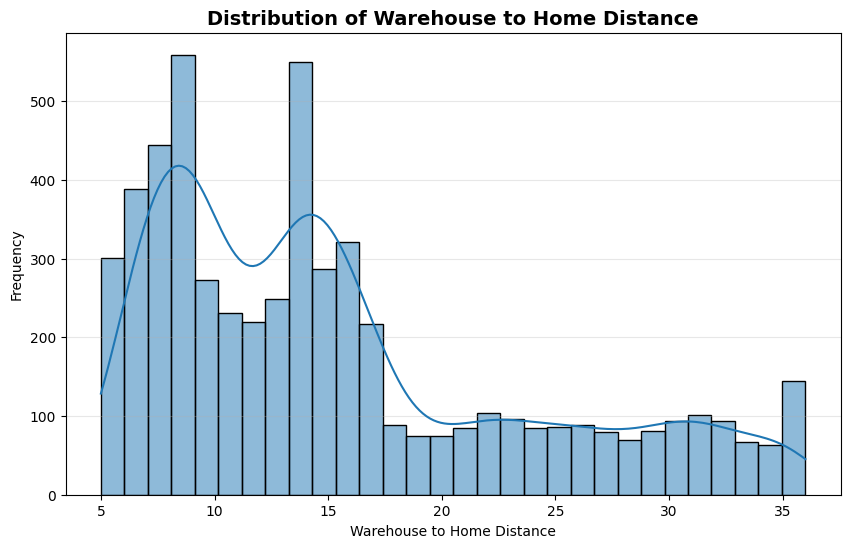

In [49]:
# Plot 32: Distribution of Warehouse to Home Distance
plt.figure(figsize=(10, 6))
sns.histplot(data=df_full, x='WarehouseToHome', kde=True, bins=30)
plt.title('Distribution of Warehouse to Home Distance', fontsize=14, fontweight='bold')
plt.xlabel('Warehouse to Home Distance')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()


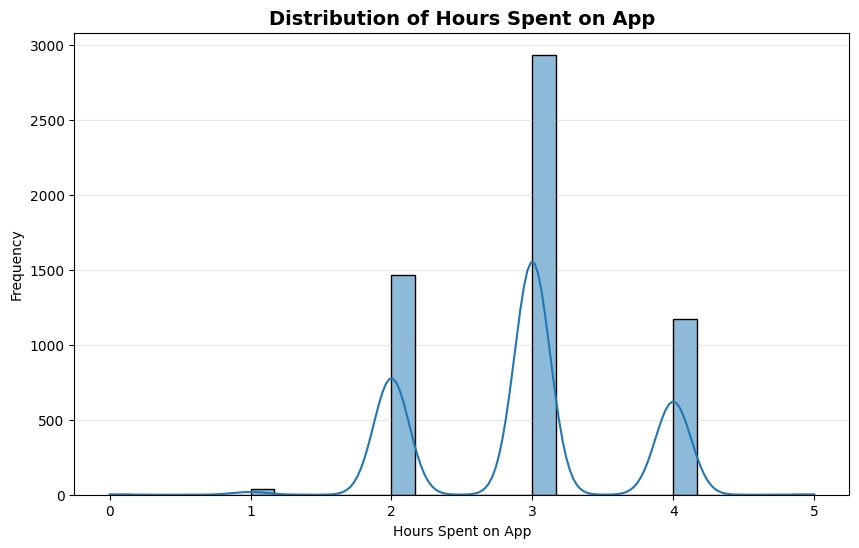

In [50]:
# Plot 33: Distribution of Hours Spent on App
plt.figure(figsize=(10, 6))
sns.histplot(data=df_full, x='HourSpendOnApp', kde=True, bins=30)
plt.title('Distribution of Hours Spent on App', fontsize=14, fontweight='bold')
plt.xlabel('Hours Spent on App')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()


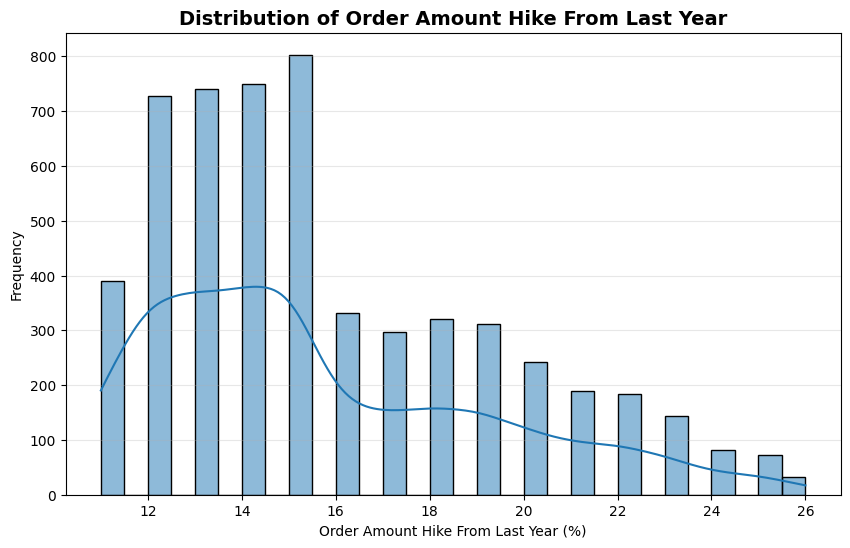

In [51]:
# Plot 34: Distribution of Order Amount Hike From Last Year
plt.figure(figsize=(10, 6))
sns.histplot(data=df_full, x='OrderAmountHikeFromlastYear', kde=True, bins=30)
plt.title('Distribution of Order Amount Hike From Last Year', fontsize=14, fontweight='bold')
plt.xlabel('Order Amount Hike From Last Year (%)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()


# Section 3: Cleaned vs. Raw Data Comparison



### Did not drop many observations from dataset. Therefore, distributions between the raw and clean dataset are very similar across all features/categories

In [54]:
# Load the raw dataset for comparison
df_raw = pd.read_excel('E_Commerce_Dataset.xlsx', sheet_name='E Comm')

print(df_raw.shape)
print(df_cleaned.shape)
print(f"Rows removed: {df_raw.shape[0] - df_cleaned.shape[0]}")
print(f"Columns removed: {df_raw.shape[1] - df_cleaned.shape[1]}")
print(f"Percentage of rows kept: {(df_cleaned.shape[0] / df_raw.shape[0]) * 100:.1f}%")


(5630, 20)
(5617, 20)
Rows removed: 13
Columns removed: 0
Percentage of rows kept: 99.8%


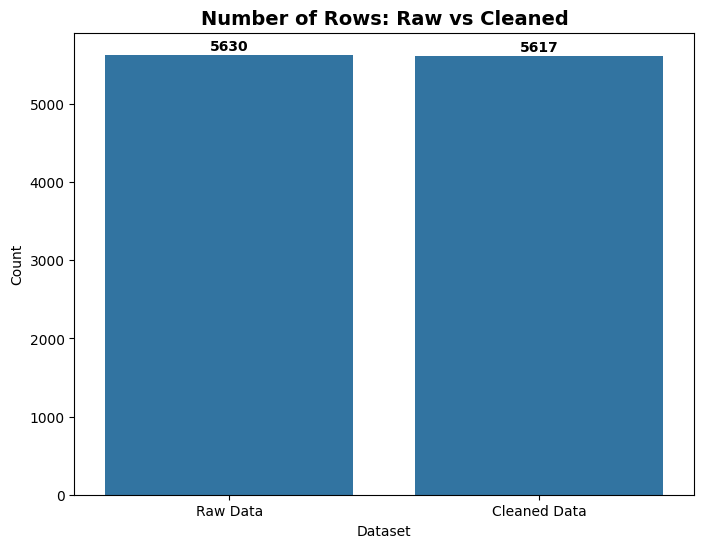

In [55]:
# Plot 36: Row Count Comparison - Raw vs Cleaned
comparison_data = pd.DataFrame({
    'Dataset': ['Raw Data', 'Cleaned Data'],
    'Number of Rows': [df_raw.shape[0], df_cleaned.shape[0]]
})

plt.figure(figsize=(8, 6))
ax = sns.barplot(data=comparison_data, x='Dataset', y='Number of Rows')
plt.title('Number of Rows: Raw vs Cleaned', fontsize=14, fontweight='bold')
plt.ylabel('Count')
for i, v in enumerate(comparison_data['Number of Rows']):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.show()


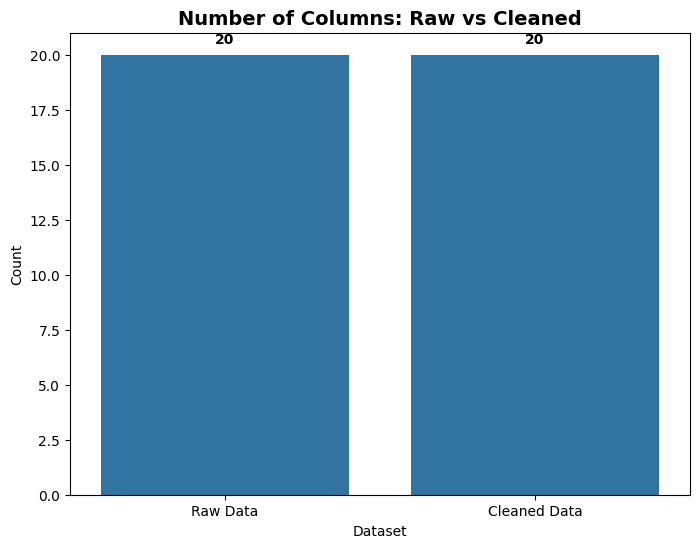

In [57]:
# Plot 37: Column Count Comparison - Raw vs Cleaned

plt.figure(figsize=(8, 6))
ax = sns.barplot(data=comparison_data, x='Dataset', y='Number of Columns')
plt.title('Number of Columns: Raw vs Cleaned', fontsize=14, fontweight='bold')
plt.ylabel('Count')
for i, v in enumerate(comparison_data['Number of Columns']):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.show()


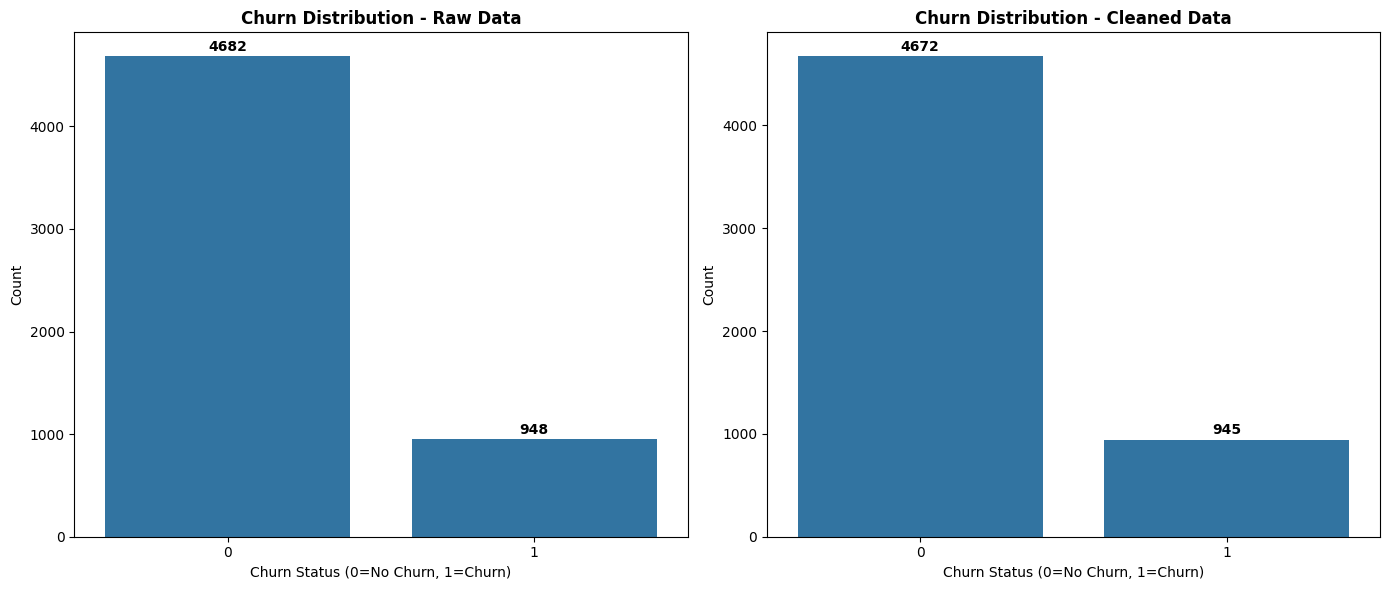

In [ ]:
# Plot 38: Distribution Comparison - Churn Variable (Raw vs Cleaned)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Raw data distribution
sns.countplot(data=df_raw, x='Churn', order=[0, 1], ax=ax1)
ax1.set_title('Churn Distribution - Raw Data', fontsize=12, fontweight='bold')
ax1.set_xlabel('Churn Status (0=No Churn, 1=Churn)')
ax1.set_ylabel('Count')
for i, v in enumerate(df_raw['Churn'].value_counts().sort_index()):
    ax1.text(i, v + 50, str(v), ha='center', fontweight='bold')

# Cleaned data distribution
sns.countplot(data=df_cleaned, x='Churn', order=[0, 1], ax=ax2)
ax2.set_title('Churn Distribution - Cleaned Data', fontsize=12, fontweight='bold')
ax2.set_xlabel('Churn Status (0=No Churn, 1=Churn)')
ax2.set_ylabel('Count')
for i, v in enumerate(df_cleaned['Churn'].value_counts().sort_index()):
    ax2.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


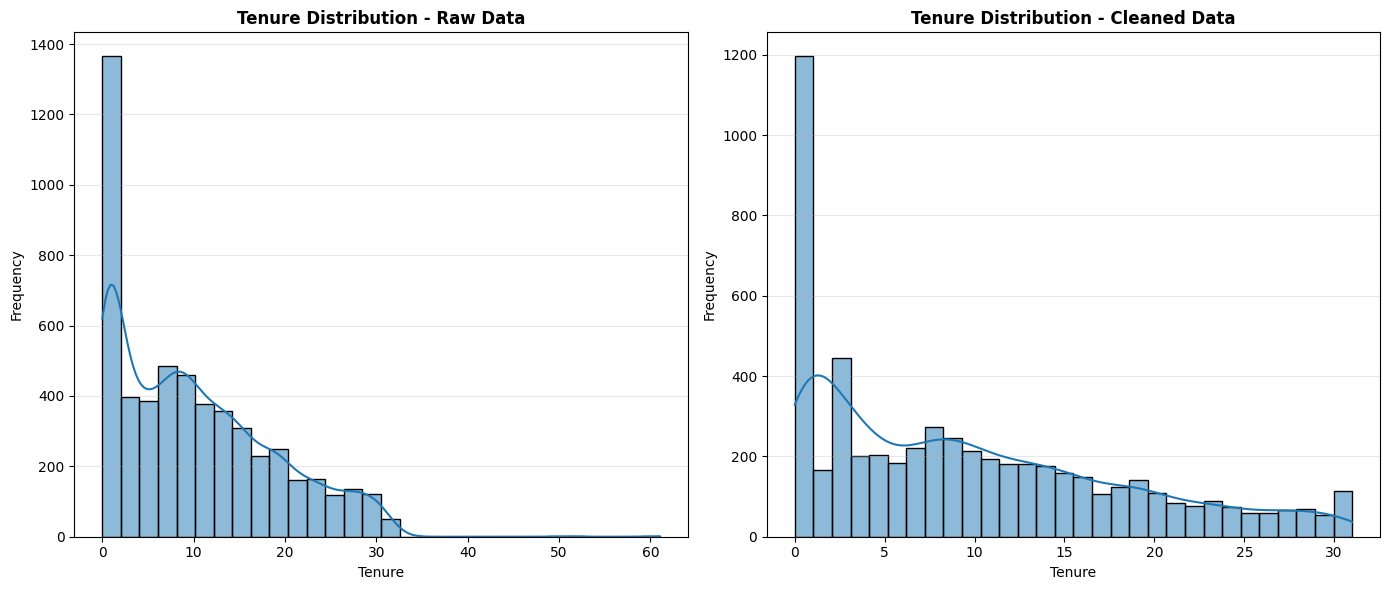

In [59]:
# Plot 39: Distribution Comparison - Tenure (Raw vs Cleaned)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Raw data distribution
sns.histplot(data=df_raw, x='Tenure', kde=True, bins=30, ax=ax1)
ax1.set_title('Tenure Distribution - Raw Data', fontsize=12, fontweight='bold')
ax1.set_xlabel('Tenure')
ax1.set_ylabel('Frequency')
ax1.grid(axis='y', alpha=0.3)

# Cleaned data distribution
sns.histplot(data=df_cleaned, x='Tenure', kde=True, bins=30, ax=ax2)
ax2.set_title('Tenure Distribution - Cleaned Data', fontsize=12, fontweight='bold')
ax2.set_xlabel('Tenure')
ax2.set_ylabel('Frequency')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


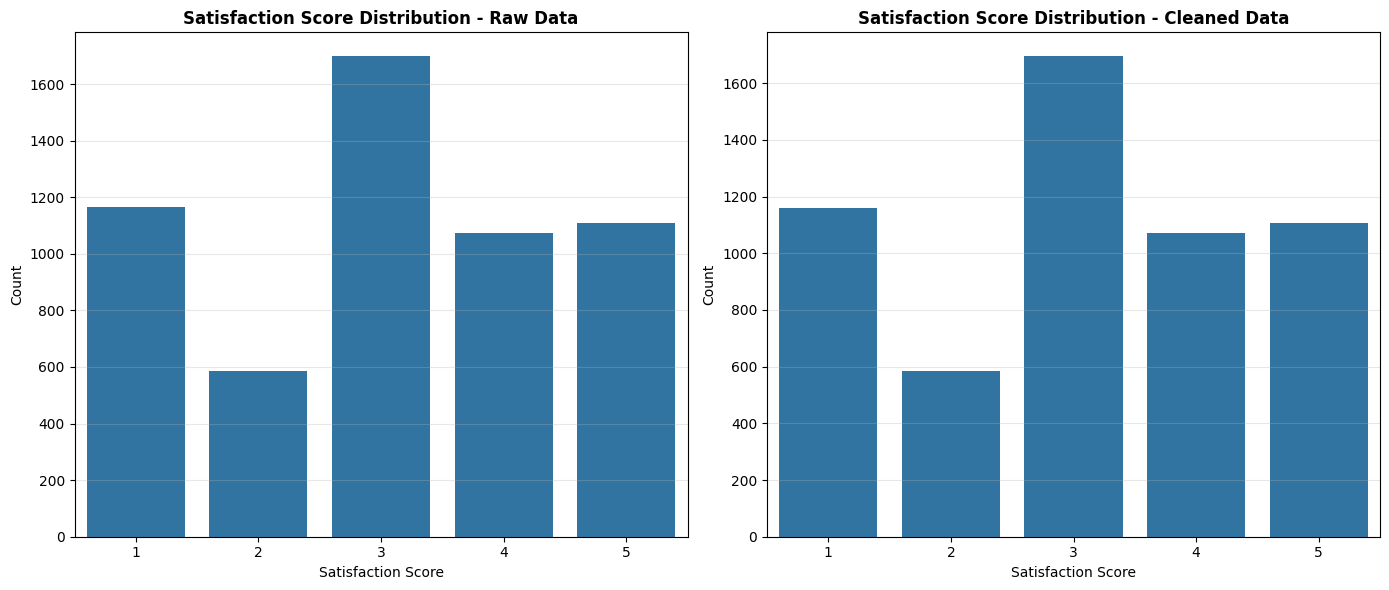

In [60]:
# Plot 40: Distribution Comparison - Satisfaction Score (Raw vs Cleaned)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Raw data distribution
sns.countplot(data=df_raw, x='SatisfactionScore', order=sorted(df_raw['SatisfactionScore'].unique()), ax=ax1)
ax1.set_title('Satisfaction Score Distribution - Raw Data', fontsize=12, fontweight='bold')
ax1.set_xlabel('Satisfaction Score')
ax1.set_ylabel('Count')
ax1.grid(axis='y', alpha=0.3)

# Cleaned data distribution
sns.countplot(data=df_cleaned, x='SatisfactionScore', order=sorted(df_cleaned['SatisfactionScore'].unique()), ax=ax2)
ax2.set_title('Satisfaction Score Distribution - Cleaned Data', fontsize=12, fontweight='bold')
ax2.set_xlabel('Satisfaction Score')
ax2.set_ylabel('Count')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


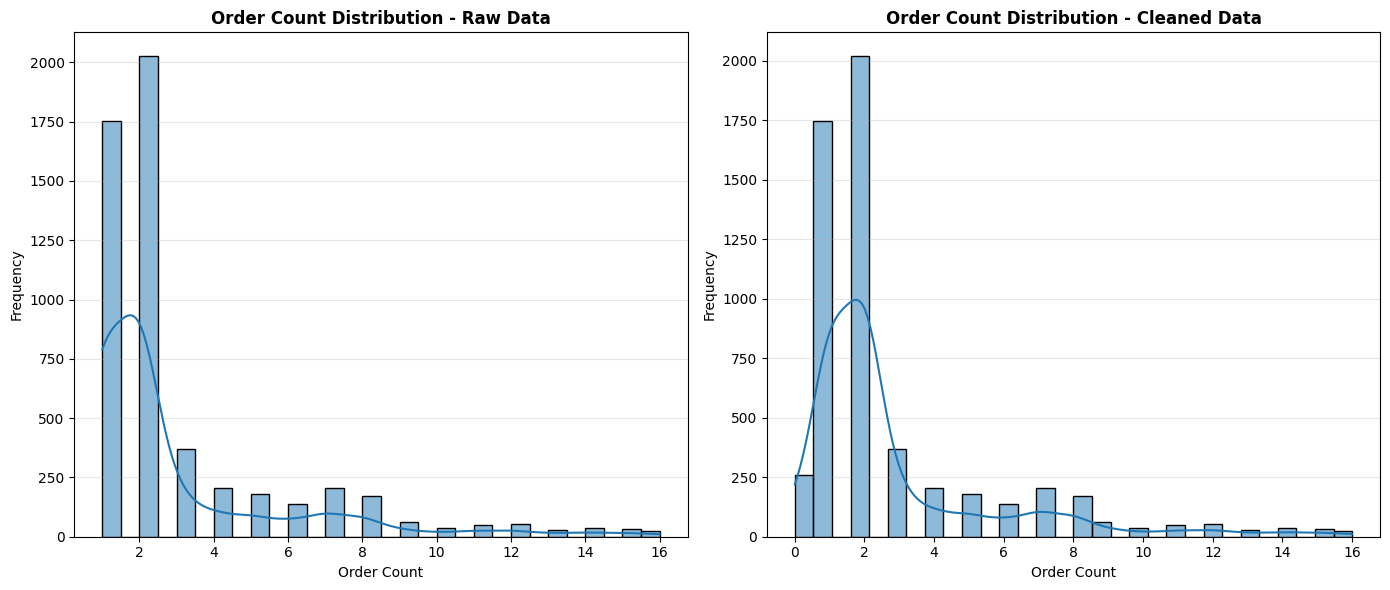

In [61]:
# Plot 41: Distribution Comparison - Order Count (Raw vs Cleaned)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Raw data distribution
sns.histplot(data=df_raw, x='OrderCount', kde=True, bins=30, ax=ax1)
ax1.set_title('Order Count Distribution - Raw Data', fontsize=12, fontweight='bold')
ax1.set_xlabel('Order Count')
ax1.set_ylabel('Frequency')
ax1.grid(axis='y', alpha=0.3)

# Cleaned data distribution
sns.histplot(data=df_cleaned, x='OrderCount', kde=True, bins=30, ax=ax2)
ax2.set_title('Order Count Distribution - Cleaned Data', fontsize=12, fontweight='bold')
ax2.set_xlabel('Order Count')
ax2.set_ylabel('Frequency')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


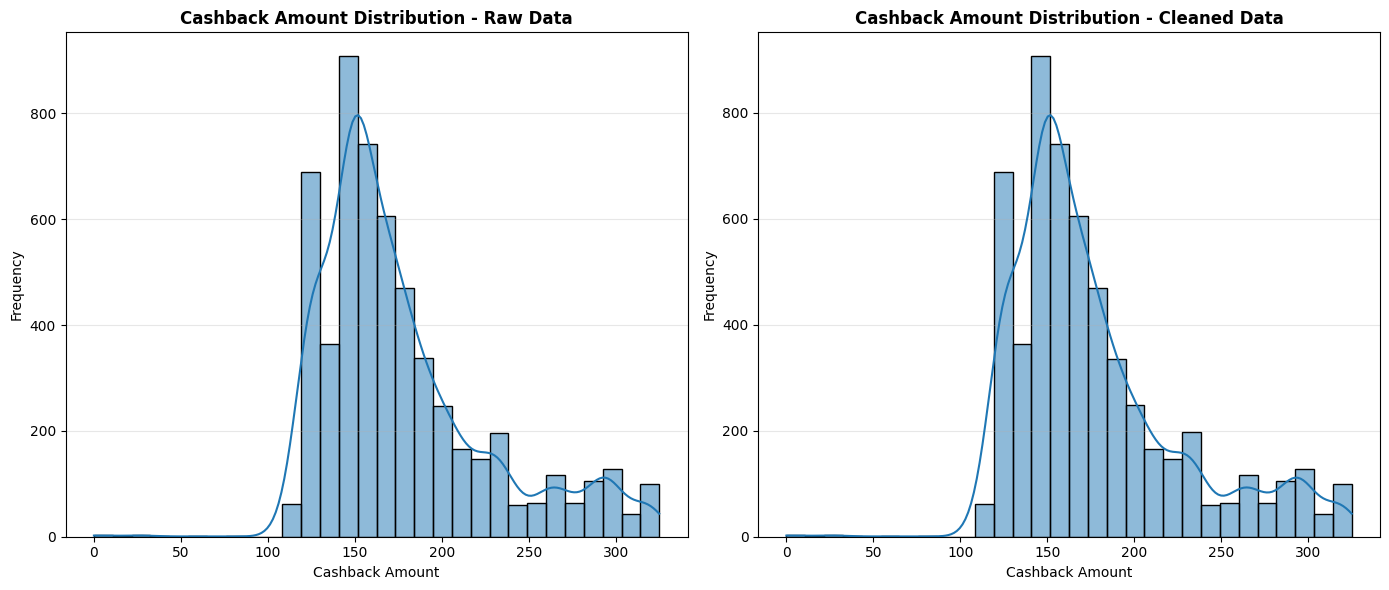

In [62]:
# Plot 42: Distribution Comparison - Cashback Amount (Raw vs Cleaned)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Raw data distribution
sns.histplot(data=df_raw, x='CashbackAmount', kde=True, bins=30, ax=ax1)
ax1.set_title('Cashback Amount Distribution - Raw Data', fontsize=12, fontweight='bold')
ax1.set_xlabel('Cashback Amount')
ax1.set_ylabel('Frequency')
ax1.grid(axis='y', alpha=0.3)

# Cleaned data distribution
sns.histplot(data=df_cleaned, x='CashbackAmount', kde=True, bins=30, ax=ax2)
ax2.set_title('Cashback Amount Distribution - Cleaned Data', fontsize=12, fontweight='bold')
ax2.set_xlabel('Cashback Amount')
ax2.set_ylabel('Frequency')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


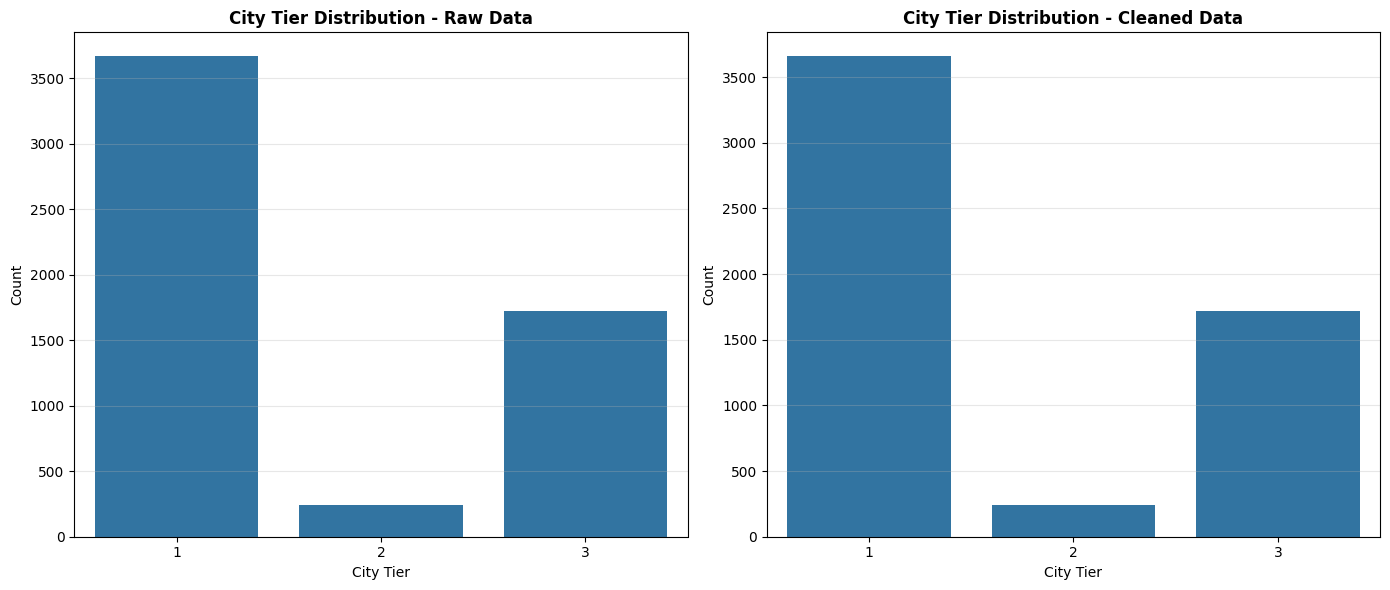

In [63]:
# Plot 43: Distribution Comparison - City Tier (Raw vs Cleaned)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Raw data distribution
sns.countplot(data=df_raw, x='CityTier', order=sorted(df_raw['CityTier'].unique()), ax=ax1)
ax1.set_title('City Tier Distribution - Raw Data', fontsize=12, fontweight='bold')
ax1.set_xlabel('City Tier')
ax1.set_ylabel('Count')
ax1.grid(axis='y', alpha=0.3)

# Cleaned data distribution
sns.countplot(data=df_cleaned, x='CityTier', order=sorted(df_cleaned['CityTier'].unique()), ax=ax2)
ax2.set_title('City Tier Distribution - Cleaned Data', fontsize=12, fontweight='bold')
ax2.set_xlabel('City Tier')
ax2.set_ylabel('Count')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


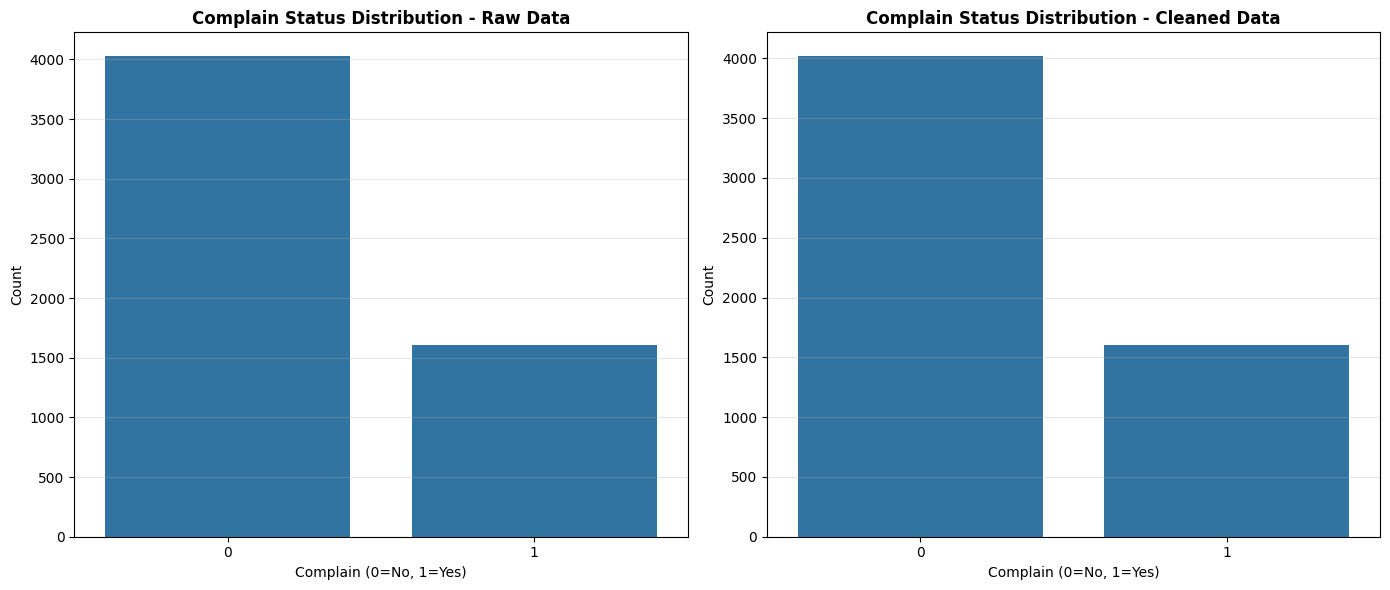

In [64]:
# Plot 44: Distribution Comparison - Complain Status (Raw vs Cleaned)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Raw data distribution
sns.countplot(data=df_raw, x='Complain', order=sorted(df_raw['Complain'].unique()), ax=ax1)
ax1.set_title('Complain Status Distribution - Raw Data', fontsize=12, fontweight='bold')
ax1.set_xlabel('Complain (0=No, 1=Yes)')
ax1.set_ylabel('Count')
ax1.grid(axis='y', alpha=0.3)

# Cleaned data distribution
sns.countplot(data=df_cleaned, x='Complain', order=sorted(df_cleaned['Complain'].unique()), ax=ax2)
ax2.set_title('Complain Status Distribution - Cleaned Data', fontsize=12, fontweight='bold')
ax2.set_xlabel('Complain (0=No, 1=Yes)')
ax2.set_ylabel('Count')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


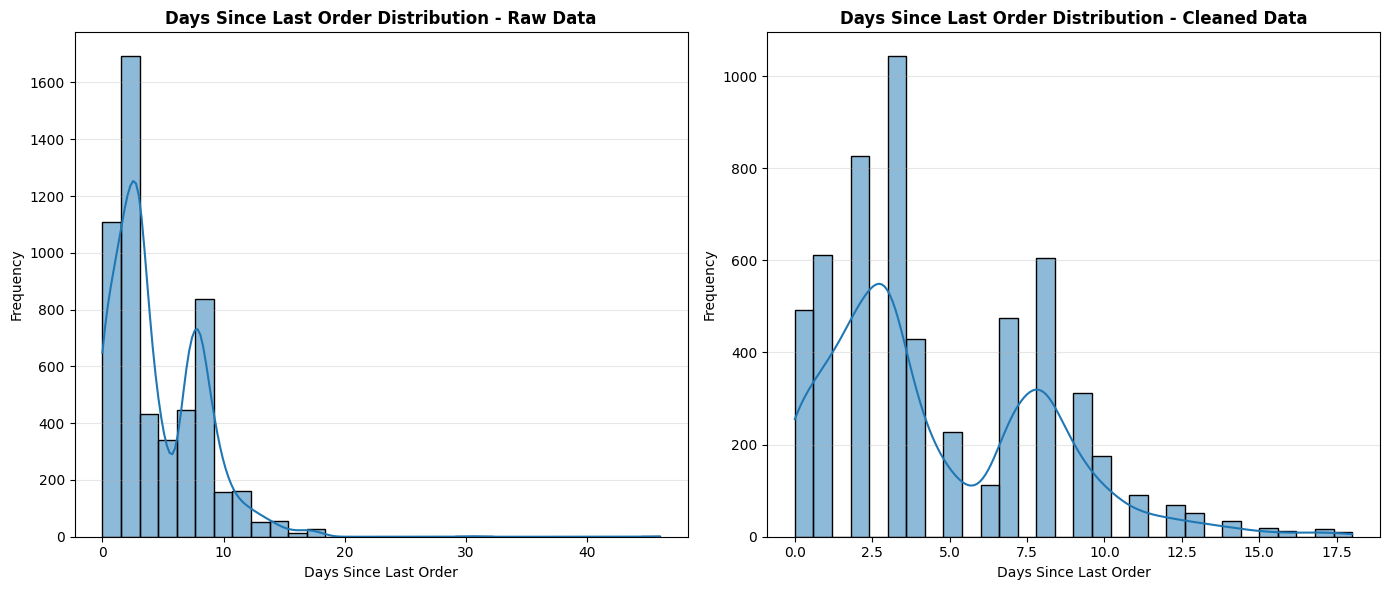

In [65]:
# Plot 45: Distribution Comparison - Days Since Last Order (Raw vs Cleaned)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Raw data distribution
sns.histplot(data=df_raw, x='DaySinceLastOrder', kde=True, bins=30, ax=ax1)
ax1.set_title('Days Since Last Order Distribution - Raw Data', fontsize=12, fontweight='bold')
ax1.set_xlabel('Days Since Last Order')
ax1.set_ylabel('Frequency')
ax1.grid(axis='y', alpha=0.3)

# Cleaned data distribution
sns.histplot(data=df_cleaned, x='DaySinceLastOrder', kde=True, bins=30, ax=ax2)
ax2.set_title('Days Since Last Order Distribution - Cleaned Data', fontsize=12, fontweight='bold')
ax2.set_xlabel('Days Since Last Order')
ax2.set_ylabel('Frequency')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


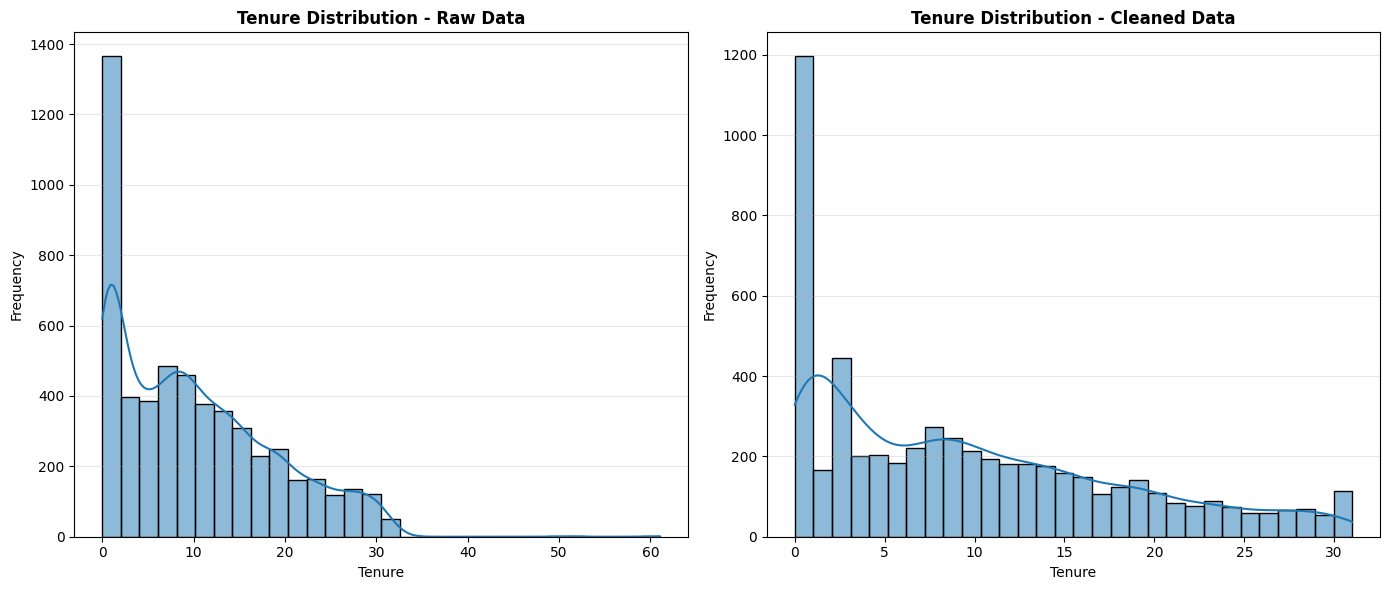

In [75]:
# Plot 46: Distribution Comparison - Tenure (Raw vs Cleaned)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Raw data distribution
sns.histplot(data=df_raw, x='Tenure', kde=True, bins=30, ax=ax1)
ax1.set_title('Tenure Distribution - Raw Data', fontsize=12, fontweight='bold')
ax1.set_xlabel('Tenure')
ax1.set_ylabel('Frequency')
ax1.grid(axis='y', alpha=0.3)

# Cleaned data distribution
sns.histplot(data=df_cleaned, x='Tenure', kde=True, bins=30, ax=ax2)
ax2.set_title('Tenure Distribution - Cleaned Data', fontsize=12, fontweight='bold')
ax2.set_xlabel('Tenure')
ax2.set_ylabel('Frequency')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


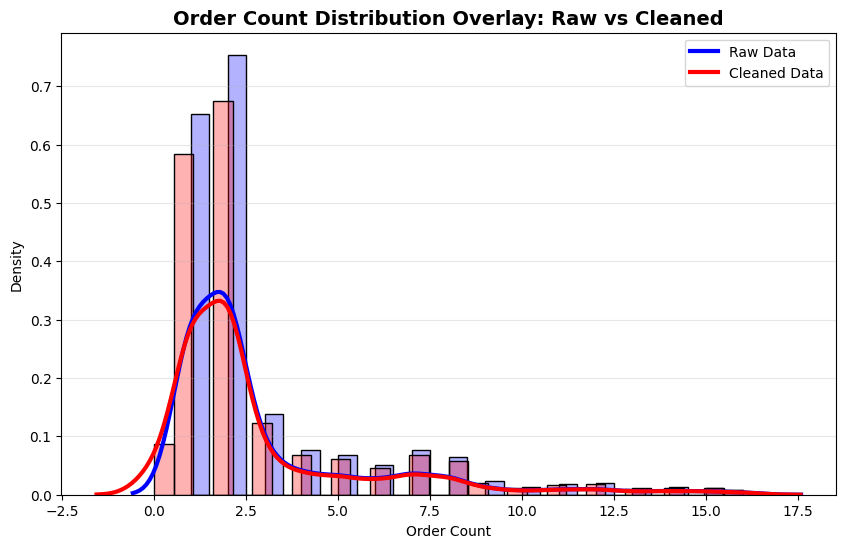

In [74]:
# Plot 47: Overlay Distribution Comparison - Order Count (Raw vs Cleaned)
plt.figure(figsize=(10, 6))
# Plot KDE curves for both datasets
sns.kdeplot(data=df_raw, x='OrderCount', label='Raw Data', linewidth=3, color='blue')
sns.kdeplot(data=df_cleaned, x='OrderCount', label='Cleaned Data', linewidth=3, color='red')
# Add histograms with low alpha
sns.histplot(data=df_raw, x='OrderCount', stat='density', bins=30, alpha=0.3, color='blue', label='')
sns.histplot(data=df_cleaned, x='OrderCount', stat='density', bins=30, alpha=0.3, color='red', label='')
plt.title('Order Count Distribution Overlay: Raw vs Cleaned', fontsize=14, fontweight='bold')
plt.xlabel('Order Count')
plt.ylabel('Density')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.show()


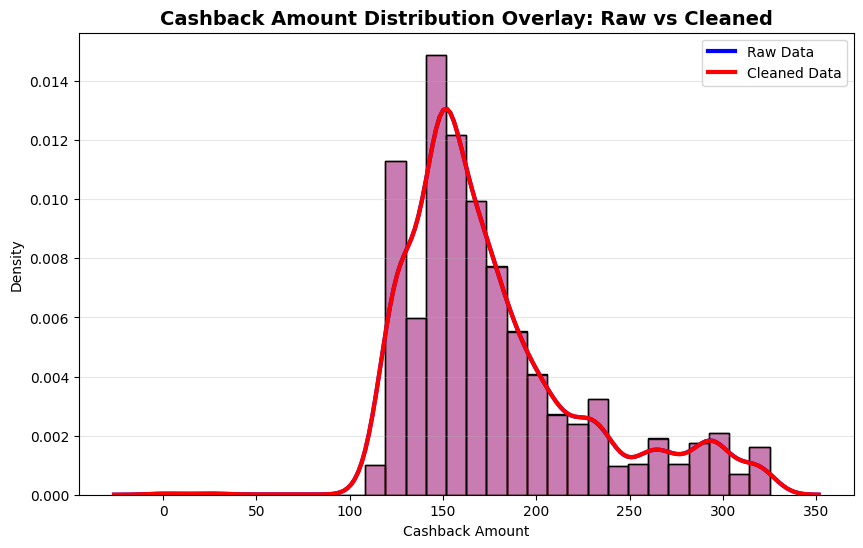

In [ ]:
# Plot 48: Overlay Distribution Comparison - Cashback Amount (Raw vs Cleaned)
plt.figure(figsize=(10, 6))
# Plot KDE curves for both datasets
sns.kdeplot(data=df_raw, x='CashbackAmount', label='Raw Data', linewidth=3, color='blue')
sns.kdeplot(data=df_cleaned, x='CashbackAmount', label='Cleaned Data', linewidth=3, color='red')
# Add histograms with low alpha
sns.histplot(data=df_raw, x='CashbackAmount', stat='density', bins=30, alpha=0.3, color='blue', label='')
sns.histplot(data=df_cleaned, x='CashbackAmount', stat='density', bins=30, alpha=0.3, color='red', label='')
plt.title('Cashback Amount Distribution Overlay: Raw vs Cleaned', fontsize=14, fontweight='bold')
plt.xlabel('Cashback Amount')
plt.ylabel('Density')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.show()
